# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 16    |  |
| :-------------|:-------------|
| Wolf Peutz| 6436102 |
| Victor Scholten | 6434789 |
| Tahlia van den Berg| 6399991 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Wolf', 'Victor','Tahlia']


## Opdracht 1: Planning.

| Planning Groep: 16     |Tijdstip / Tijdspanne  |
|---|---|
| kalibreren sensor | 11:30 |
| testen meetopstelling | 12:00 |
| Iteratie 0 | 14:15 |
| Iteratie 1+ | 15:30 |
| volledig inleveren | 17:30 |
| groep aanwezig 1| 11:00 |
| groep aanwezig 2| 13:30 |
| Pauze 1| 12:30-13:30 |
| Pauze 2| 16:00-16:15 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [16]
<img src="kalibratiefoto.png" width="400">

Fit parameters: a=0.03665438650813888, b=-6.107393055219614


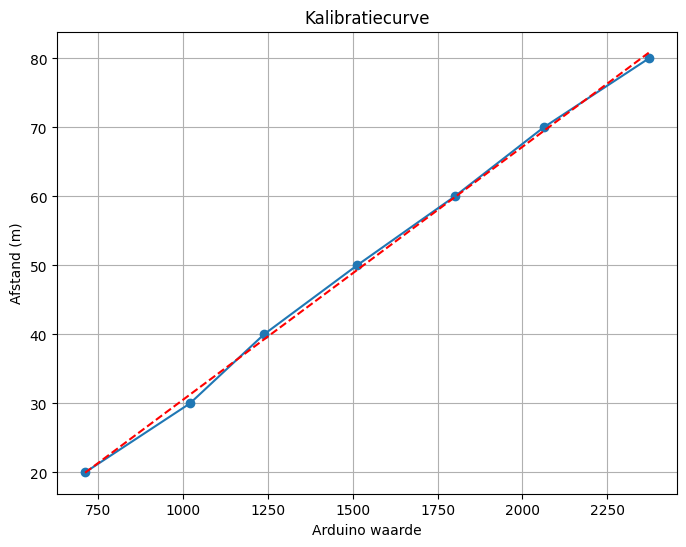

   Afstand  Arduino
0       20      711
1       30     1020
2       40     1238
3       50     1512
4       60     1800
5       70     2062
6       80     2372


In [3]:
from scipy.optimize import curve_fit
# verwerk hier jullie kalibratiemetingen
afstanden = np.array([20,30, 40,50, 60,70, 80]) #m
arduinovalue = np.array([711, 1020, 1238,1512, 1800, 2062, 2372])
 #bits
kalibratieData = pd.DataFrame({'Afstand': afstanden, 'Arduino': arduinovalue})

#fit:
def fitfunc(x, a, b):
    return a * x + b
popt, pcov = curve_fit(fitfunc, kalibratieData['Arduino'], kalibratieData['Afstand'])
print(f'Fit parameters: a={popt[0]}, b={popt[1]}')

x_test = np.linspace(min(kalibratieData['Arduino']), max(kalibratieData['Arduino']), 100)
# plot de kalibratiecurve
plt.figure(figsize=(8, 6))
plt.plot(kalibratieData['Arduino'],kalibratieData['Afstand'],  'o-')
plt.plot(x_test, fitfunc(x_test, *popt), 'r--', label='Fit: a={:.2f}, b={:.2f}'.format(*popt))
plt.xlabel('Arduino waarde')  
plt.ylabel('Afstand (m)')
plt.title('Kalibratiecurve') 
plt.grid()
plt.show()
print(kalibratieData)


## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  39.99
1   0  30   0  20  40.40
2  40   0  30   0  41.25
3  30   0  20   0  41.18


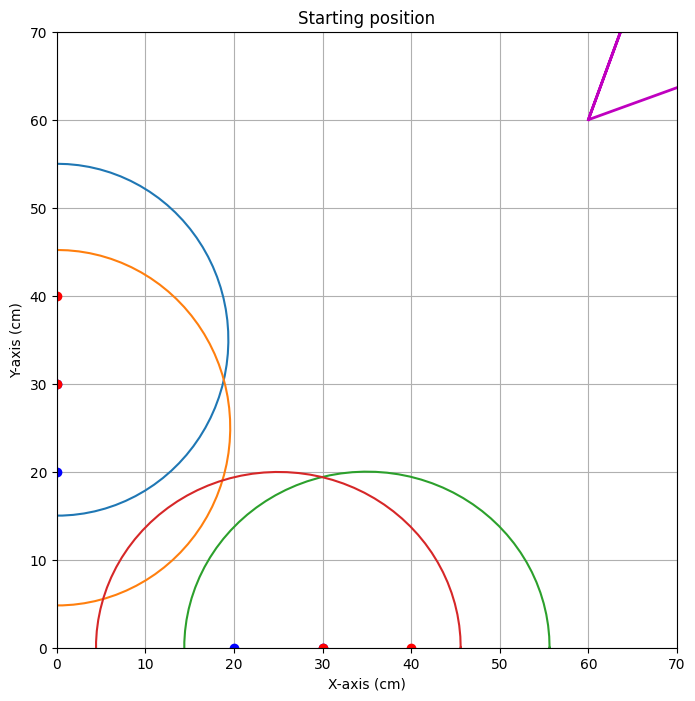


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=101.250


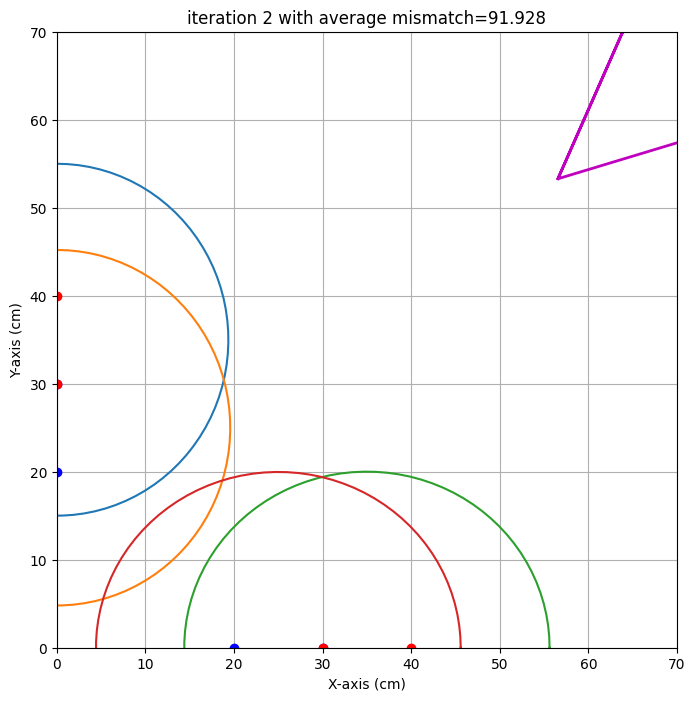

end iteration 2 with average mismatch=91.928


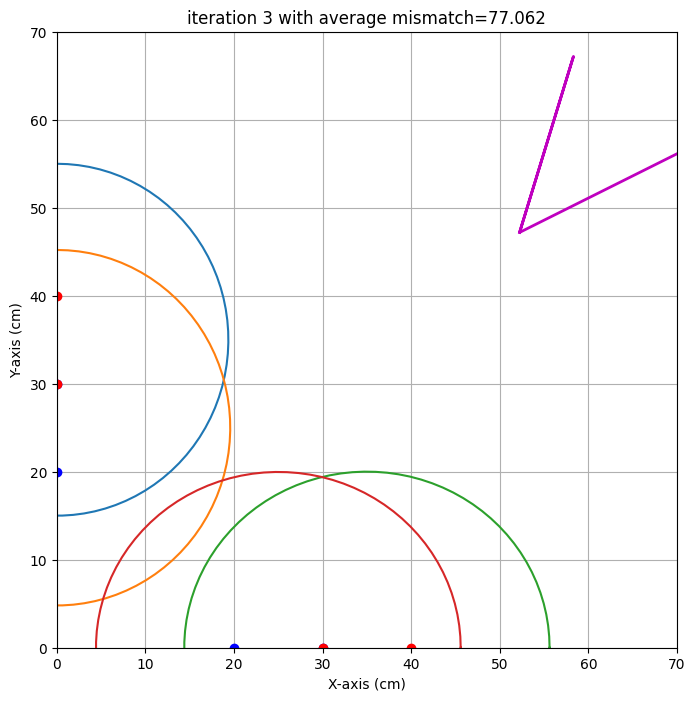

end iteration 3 with average mismatch=77.062


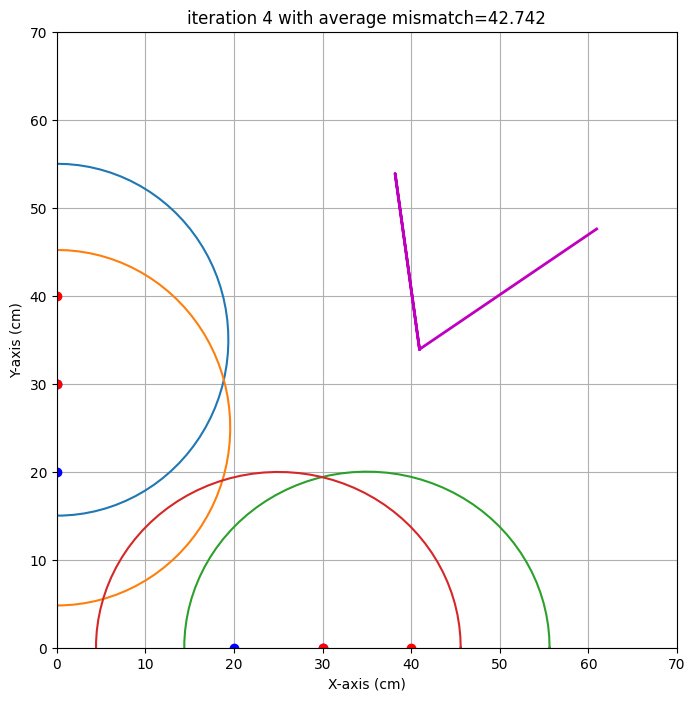

end iteration 4 with average mismatch=42.742


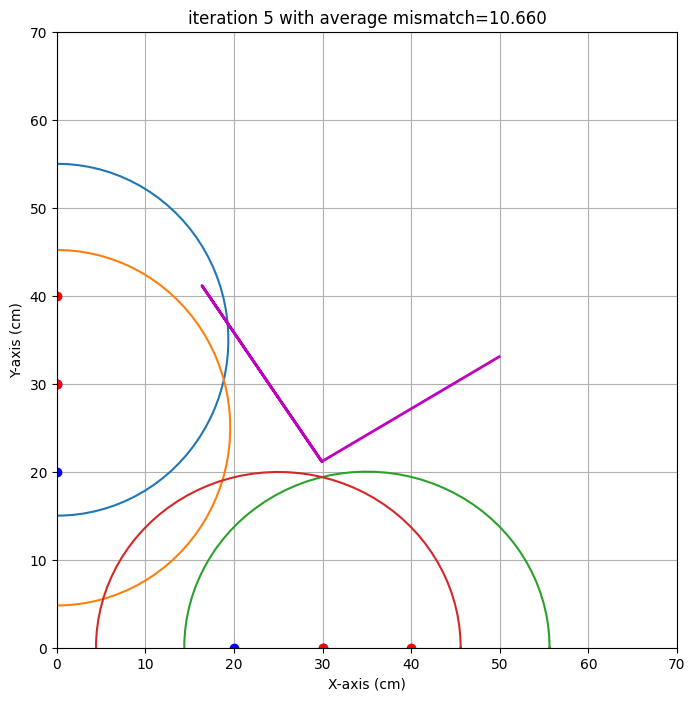

end iteration 5 with average mismatch=10.660


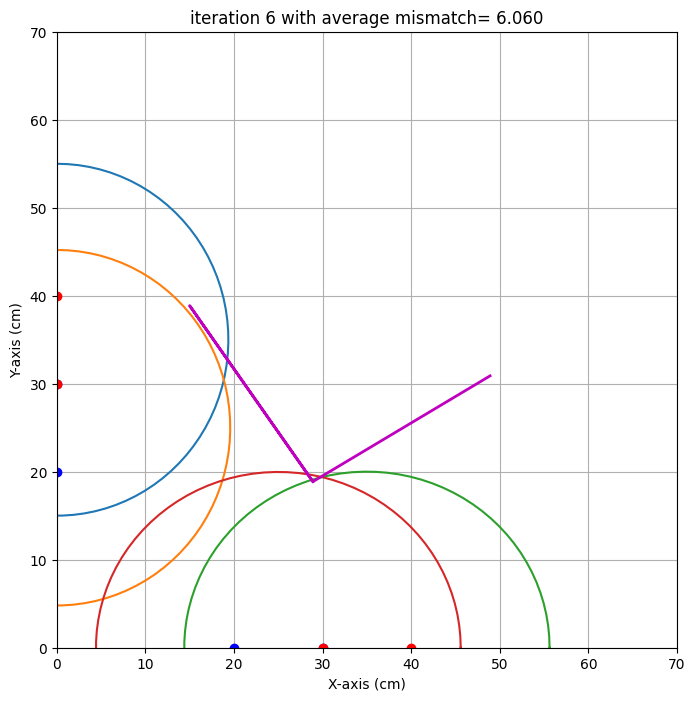

end iteration 6 with average mismatch= 6.060


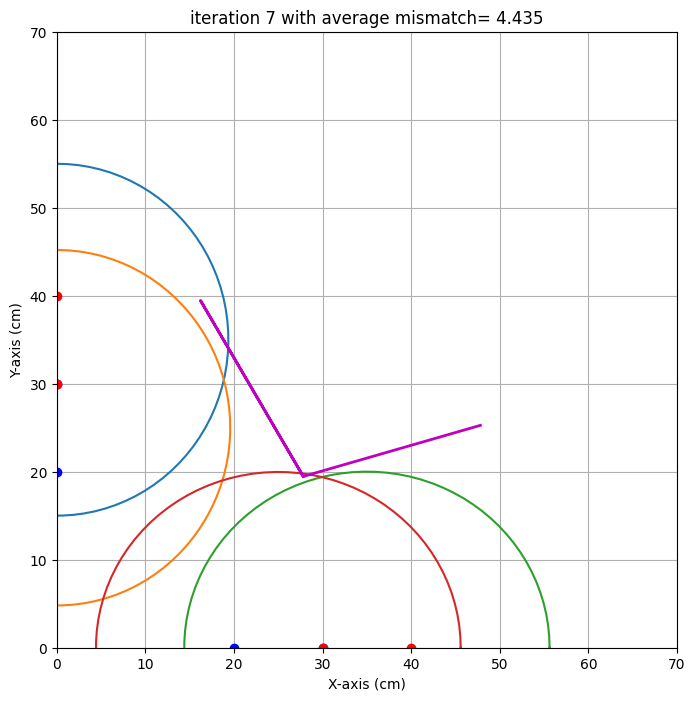

end iteration 7 with average mismatch= 4.435


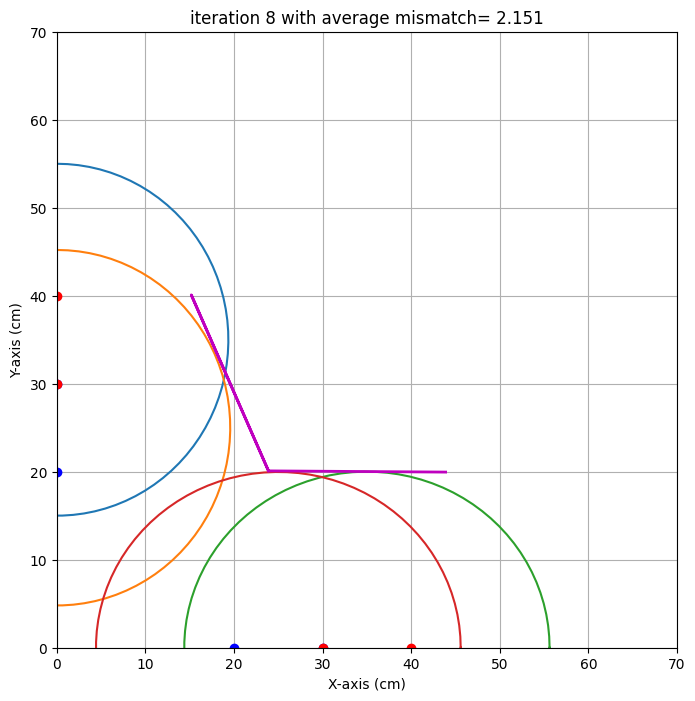

end iteration 8 with average mismatch= 2.151
end iteration 9 with average mismatch= 2.136
end iteration 10 with average mismatch= 1.986
end iteration 11 with average mismatch= 1.908
end iteration 12 with average mismatch= 1.786


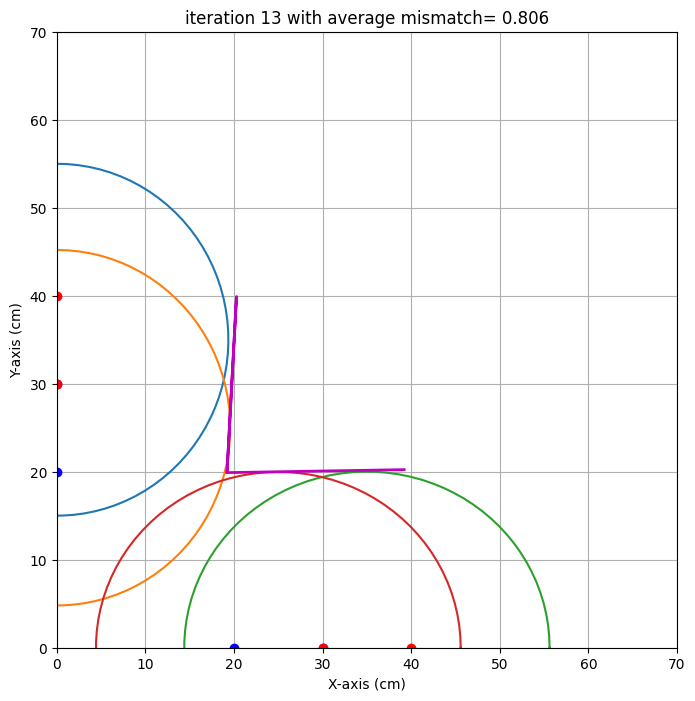

end iteration 13 with average mismatch= 0.806


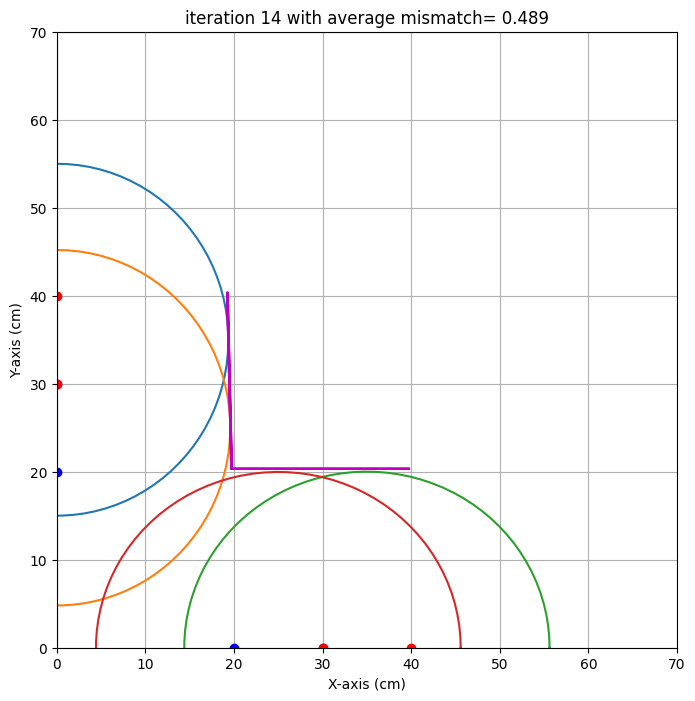

end iteration 14 with average mismatch= 0.489


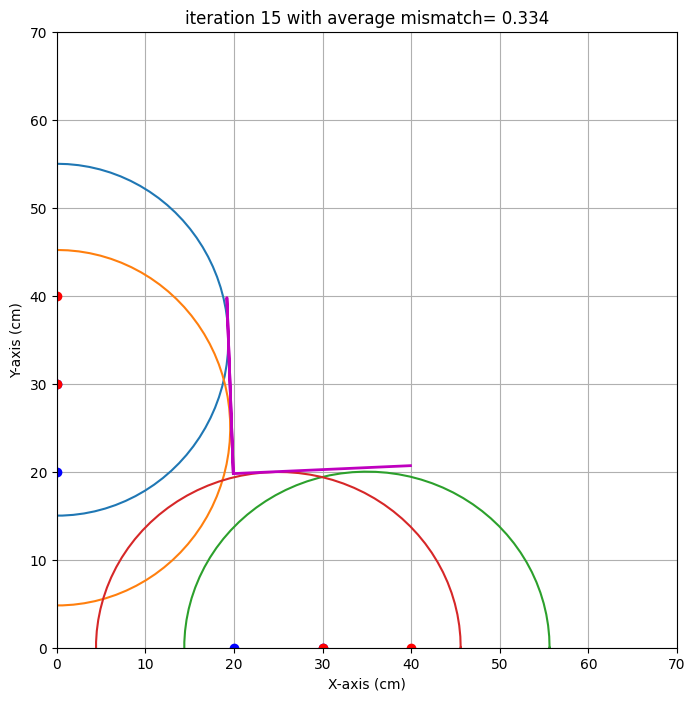

end iteration 15 with average mismatch= 0.334
end iteration 16 with average mismatch= 0.331
end iteration 17 with average mismatch= 0.330
end iteration 18 with average mismatch= 0.330
end iteration 19 with average mismatch= 0.330
end iteration 20 with average mismatch= 0.330
end iteration 21 with average mismatch= 0.330
end iteration 22 with average mismatch= 0.330
end iteration 23 with average mismatch= 0.330
end iteration 24 with average mismatch= 0.317
end iteration 25 with average mismatch= 0.287
end iteration 26 with average mismatch= 0.268
end iteration 27 with average mismatch= 0.249
end iteration 28 with average mismatch= 0.244
end iteration 29 with average mismatch= 0.243
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.243
###############################################################################
end of iteration  30
Best alpha=  -0.26 with uncer

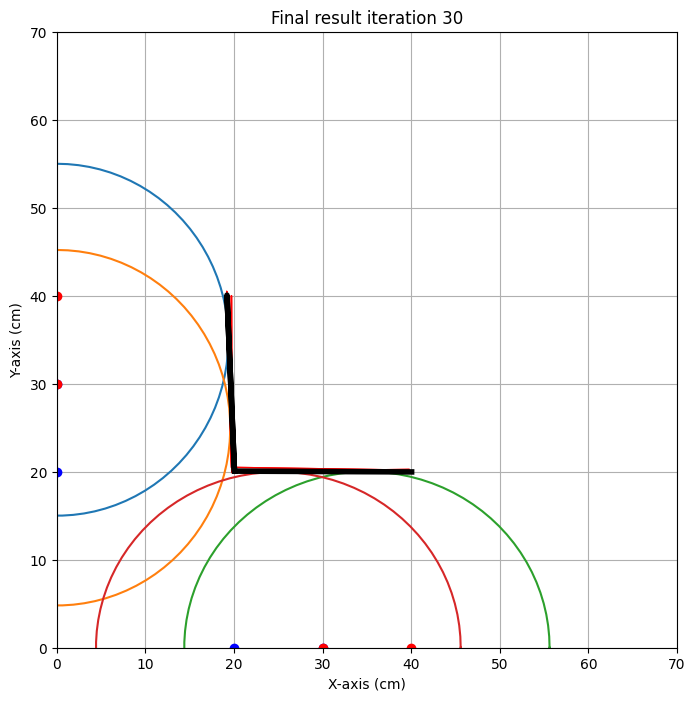

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,39.99],
    [0,30,0,20,40.40],
    #[0,10,0,20,188.77],#ongeldige meting
    [40,0,30,0,41.25],
    [30,0,20,0,41.18]
    #[10,0,20,0,144.28],#ongeldige meting
    #[10,0,0,10,136.37] #ongeldige meting   
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 20.0 cm met een standaardafwijking van 0.3 cm 
y0: 20.1 cm met een standaardafwijking van 0.4 cm 
alpha: -0.3 graden met een standaardafwijking van 1.0 graad 
beta: -2.4 graden met een standaardafwijking van 2.3 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Tahlia]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="fototahlia.png" width="400">

#### algoritme [Wolf]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="fotowolf.png" width="400">

#### algoritme [Victor]
Voeg een foto in van het algoritme van het derde groepslid
<img src="fotovictor.png" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 23,  #cm,
           'y0': 27,  #cm,
           'alpha' : 0,  #zelf aanvullen, graden
           'beta' : 33 #zelf aanvullen}, graden
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={
'Tahlia' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[0,50,0,35,ongeldig],
    [30,0, 45, 0, 56.6],
    [40,0,25,0,55.9 ],
    [0,70,0,55, 71.4],
    [0,50,0,65, 67.5]
    ]),
       'Wolf' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [20,0,0,20, 26.9],
    [40,0,0,40,55.8],
    [60,0,0,60, 87.0],
    #[65,0,0,65, ongeldig],
    [0,65, 0, 60, 77.8]
   #[65, 0, 60,0, ongeldig]
    ])
   #     'naam3' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
   #  #zelf aanvullen
   #  ])
      }
studentNames = ['Tahlia', 'Wolf']


In [8]:
#deze cell is niet van toepassing

# resultaat = dict()
# for studentName in studentNames:
#     print(studentName)
#     resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
#     print(resultaat[studentName])

In [9]:
#deze cell is niet van toepassing

# data ={'Tahlia' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
#     #[0,50,0,35,ongeldig],
#     [30,0, 45, 0, 56.6],
#     [40,0,25,0,55.9 ],
#     [0,70,0,55, 71.4],
#     [0,50,0,65, 67.5]
#     ])}
# studentNames = ['Tahlia']

## Opdracht 7: Evaluatie.

Tahlia
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  30   0  45   0  56.6
1  40   0  25   0  55.9
2   0  70   0  55  71.4
3   0  50   0  65  67.5


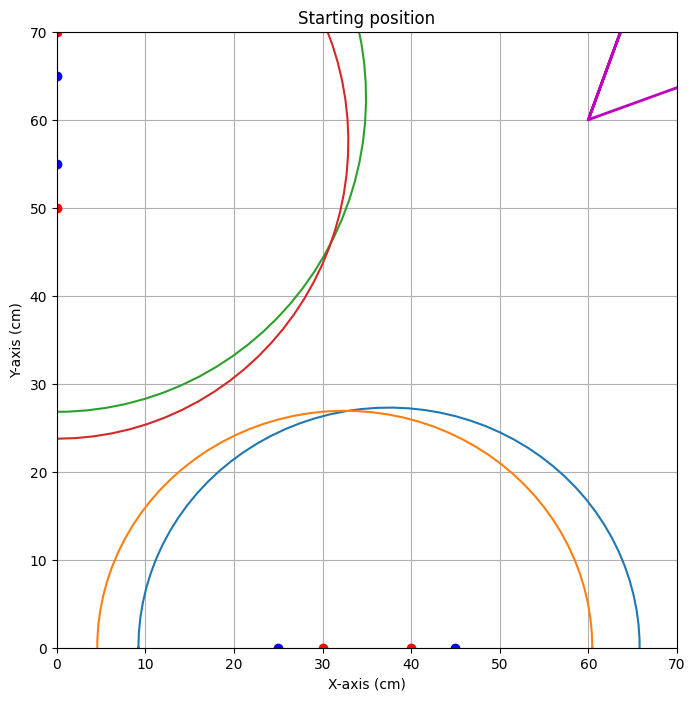


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=68.333


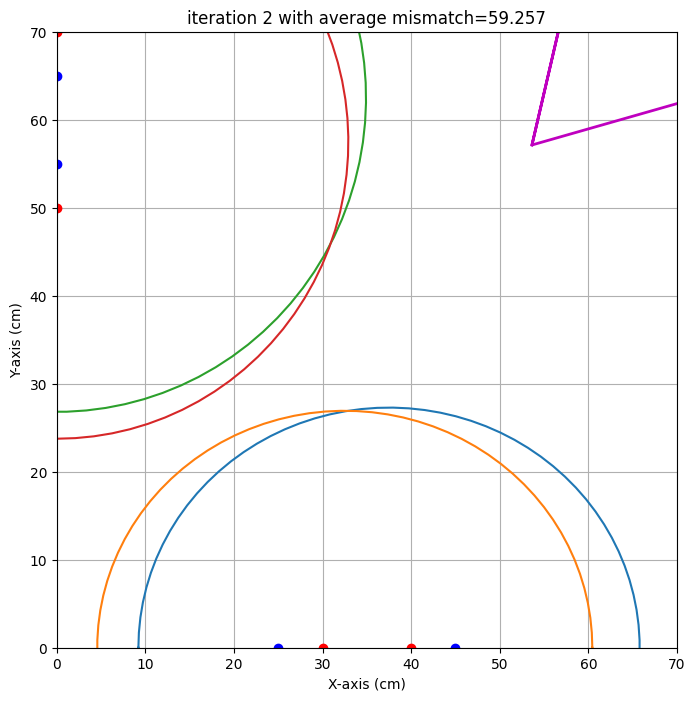

end iteration 2 with average mismatch=59.257


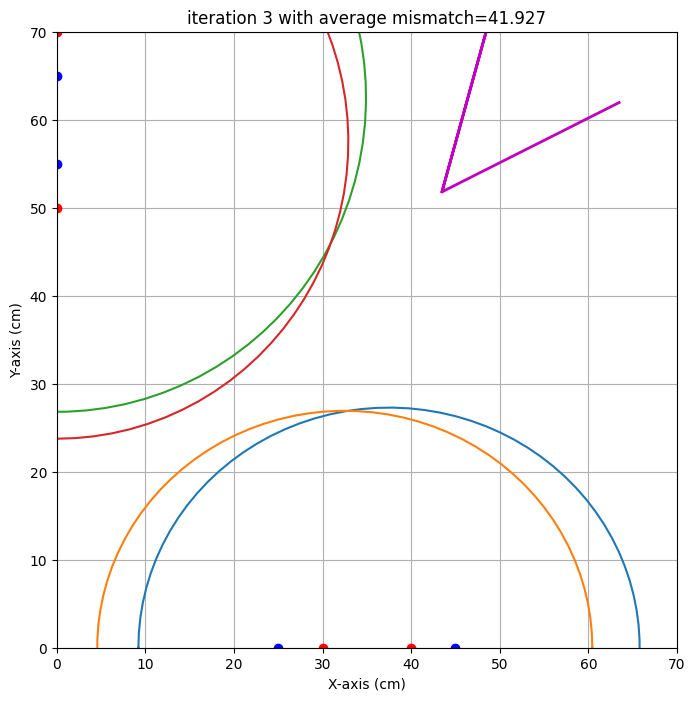

end iteration 3 with average mismatch=41.927


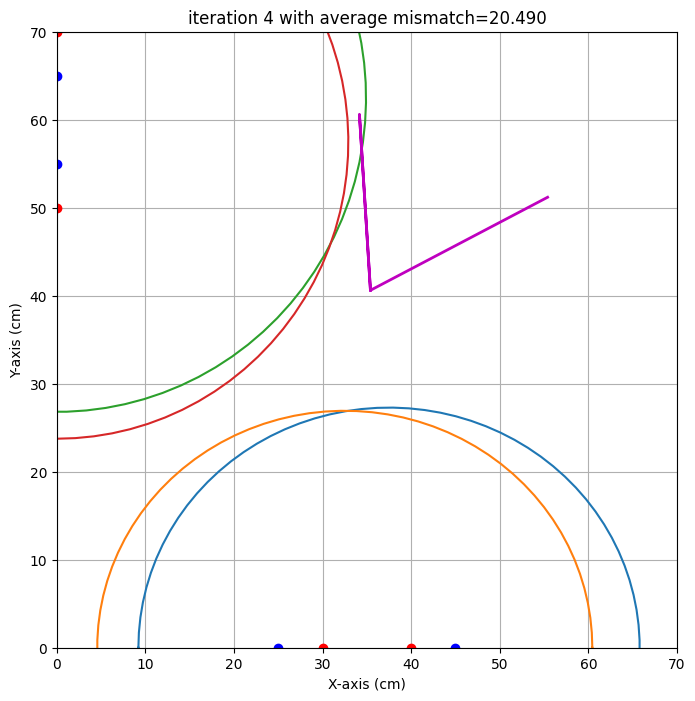

end iteration 4 with average mismatch=20.490


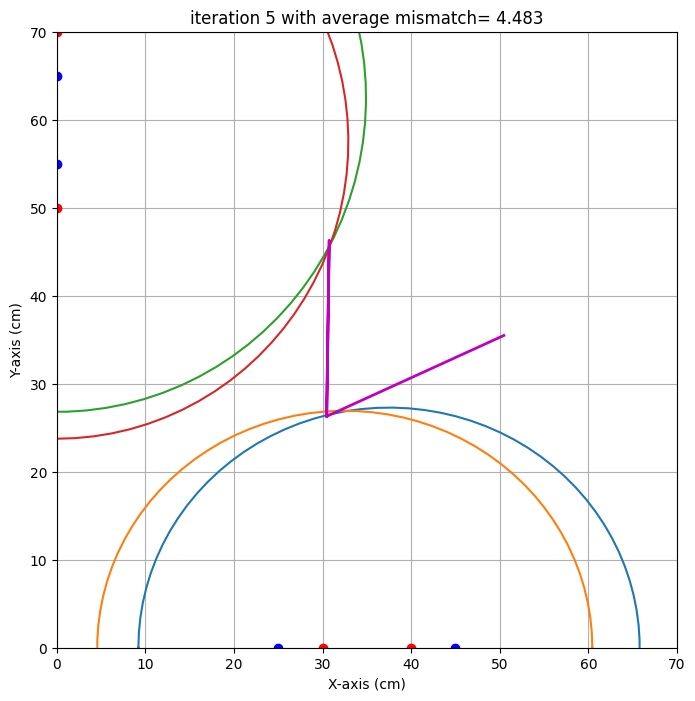

end iteration 5 with average mismatch= 4.483
end iteration 6 with average mismatch= 4.382


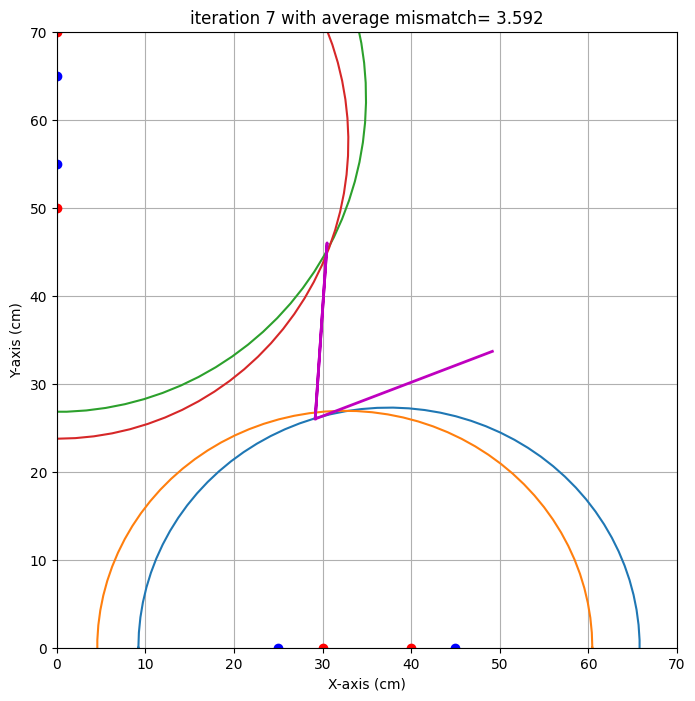

end iteration 7 with average mismatch= 3.592
end iteration 8 with average mismatch= 3.592


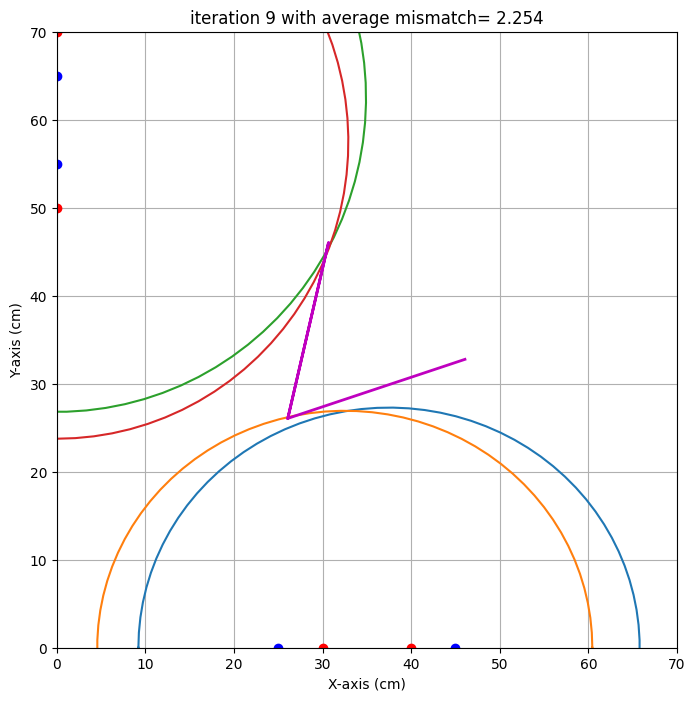

end iteration 9 with average mismatch= 2.254


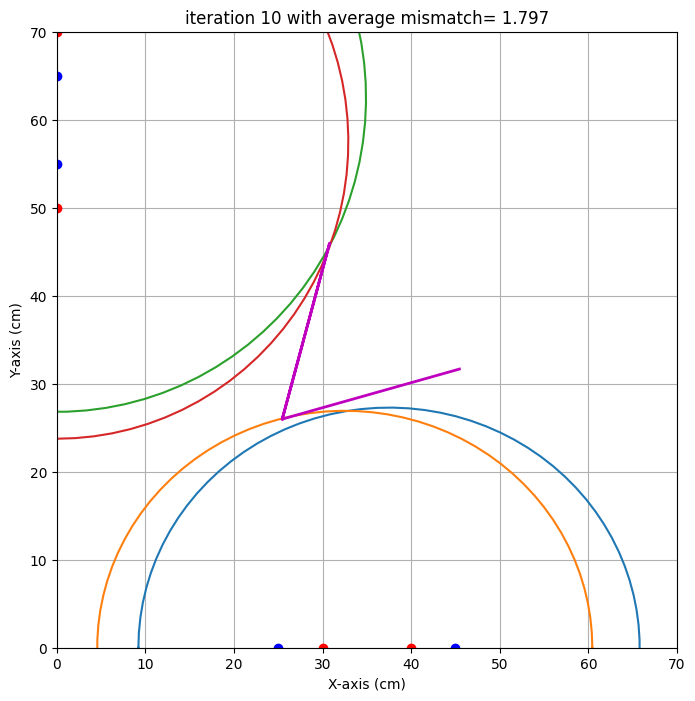

end iteration 10 with average mismatch= 1.797


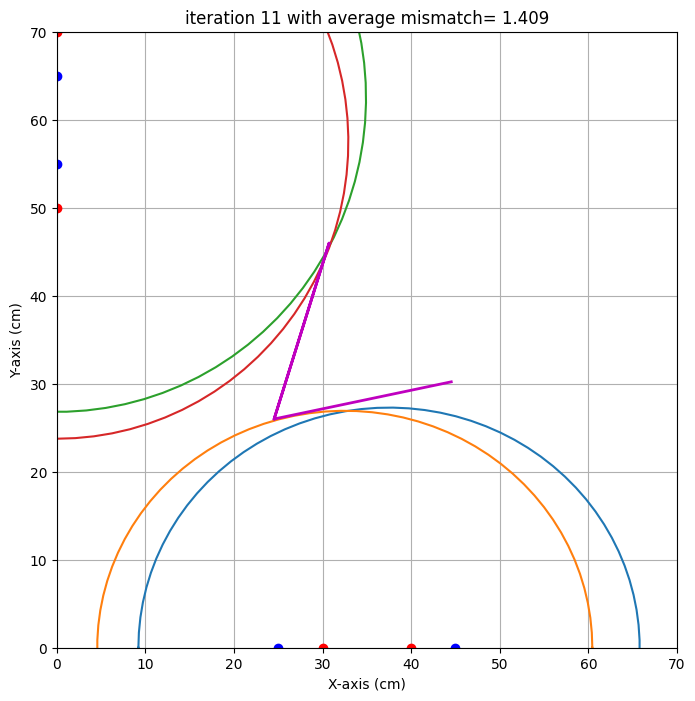

end iteration 11 with average mismatch= 1.409


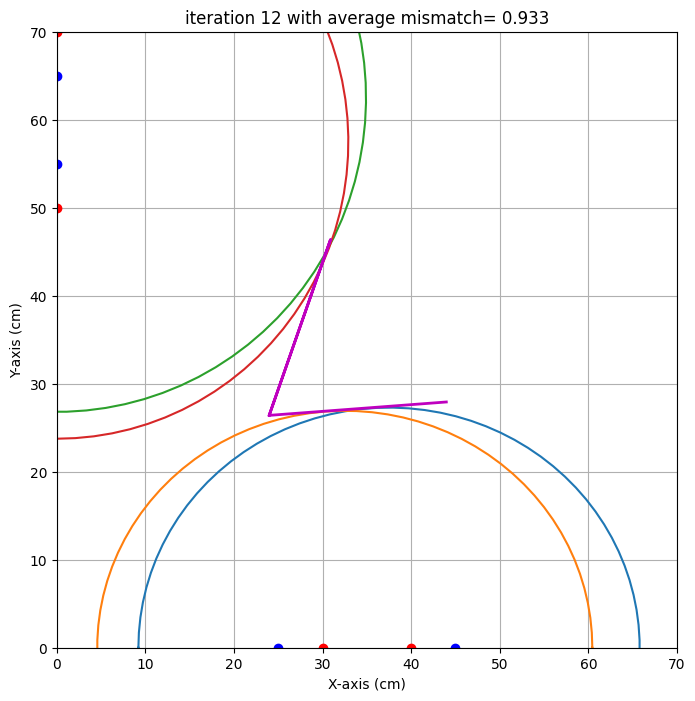

end iteration 12 with average mismatch= 0.933


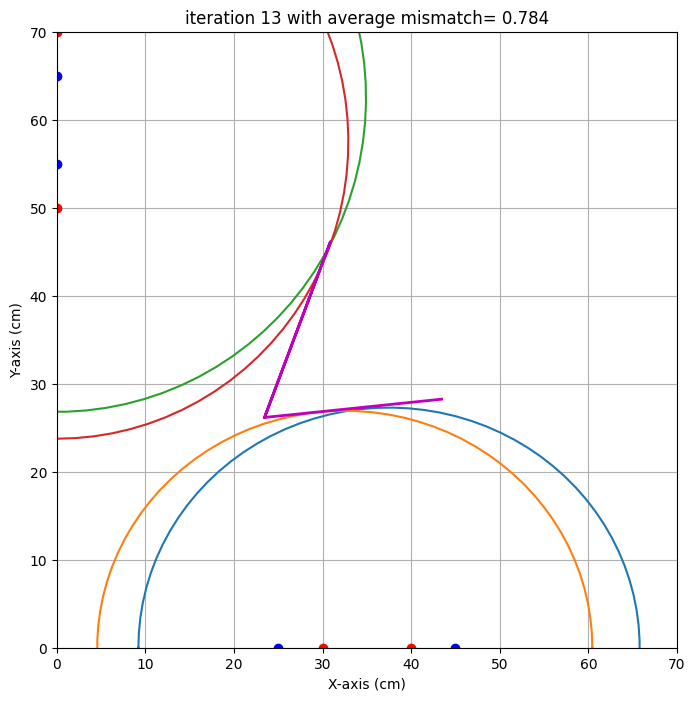

end iteration 13 with average mismatch= 0.784
end iteration 14 with average mismatch= 0.784
end iteration 15 with average mismatch= 0.784
end iteration 16 with average mismatch= 0.784
end iteration 17 with average mismatch= 0.712
end iteration 18 with average mismatch= 0.712
end iteration 19 with average mismatch= 0.712
end iteration 20 with average mismatch= 0.712


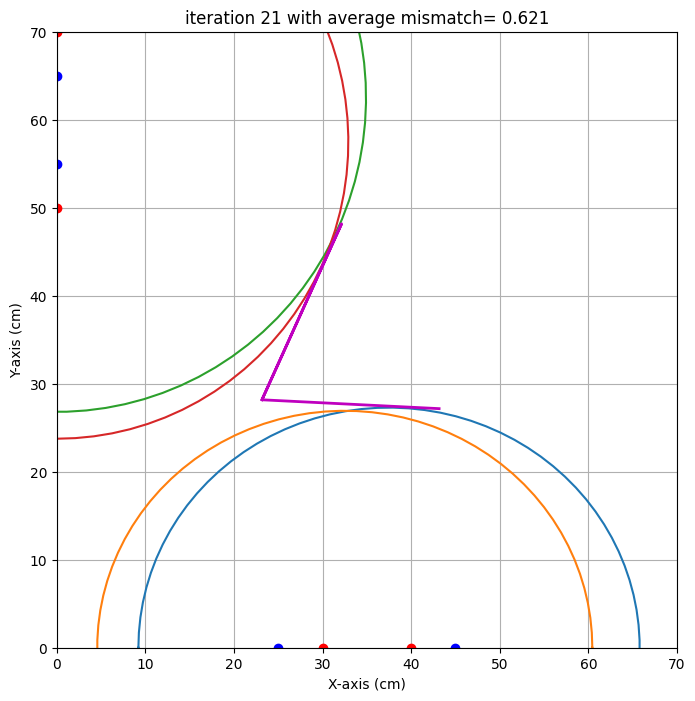

end iteration 21 with average mismatch= 0.621


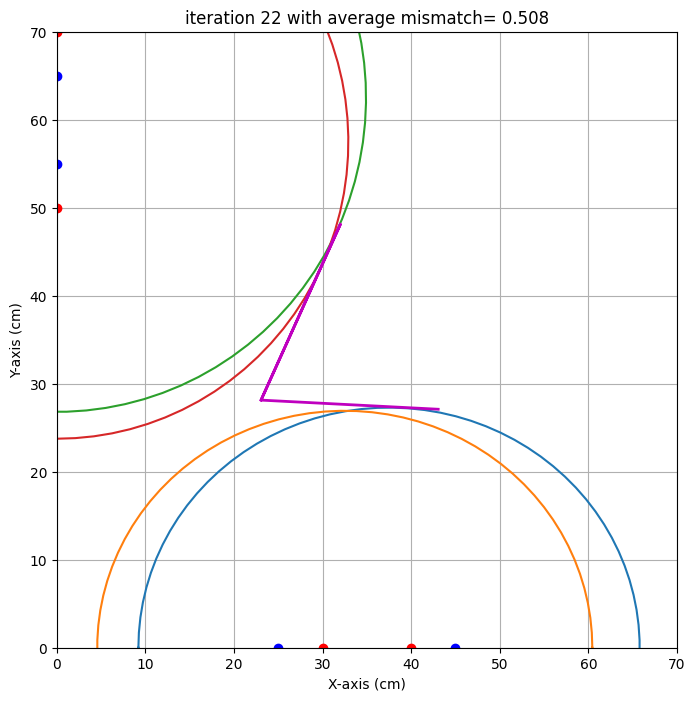

end iteration 22 with average mismatch= 0.508


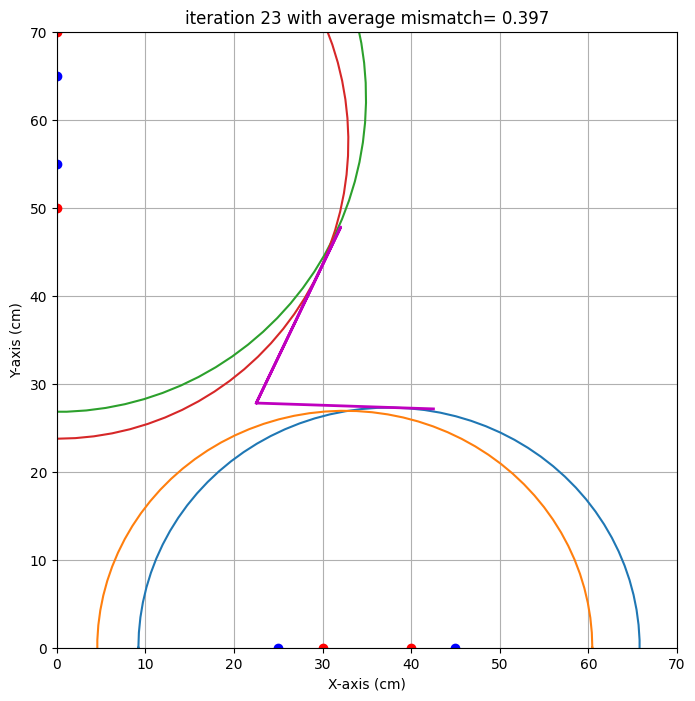

end iteration 23 with average mismatch= 0.397
end iteration 24 with average mismatch= 0.387
end iteration 25 with average mismatch= 0.385
end iteration 26 with average mismatch= 0.385
end iteration 27 with average mismatch= 0.385
end iteration 28 with average mismatch= 0.385
end iteration 29 with average mismatch= 0.385
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.385
###############################################################################
end of iteration  30
Best alpha=  -1.91 with uncertainty=   9.21
Best beta =  25.48 with uncertainty=   8.93
Best x0   =  22.50 with uncertainty=   3.47
Best y0   =  27.80 with uncertainty=   2.17
###############################################################################


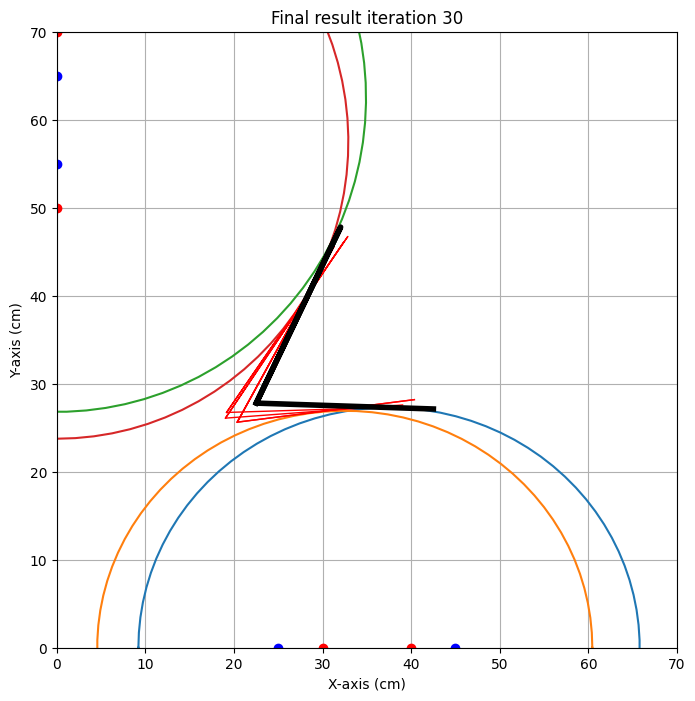

{'alpha': np.float64(-1.910404220706738), 'alpha_eps': np.float64(9.208520391164292), 'beta': np.float64(25.480357752395797), 'beta_eps': np.float64(8.925370408903675), 'x0': np.float64(22.50421811530725), 'x0_eps': np.float64(3.474829169424062), 'y0': np.float64(27.796504701275495), 'y0_eps': np.float64(2.165255209911688)}
Wolf
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  20   0   0  20  26.9
1  40   0   0  40  55.8
2  60   0   0  60  87.0
3   0  65   0  60  77.8


C:\Users\victo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


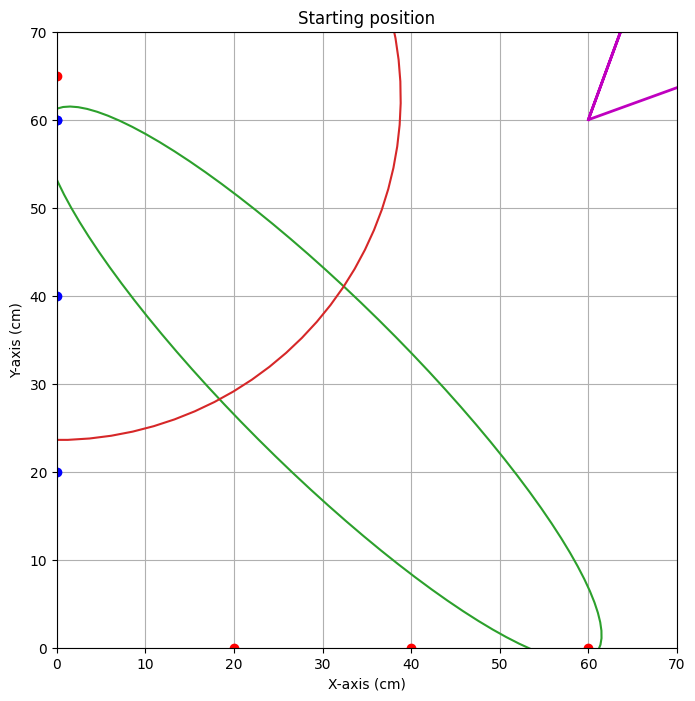


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=71.009


C:\Users\victo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


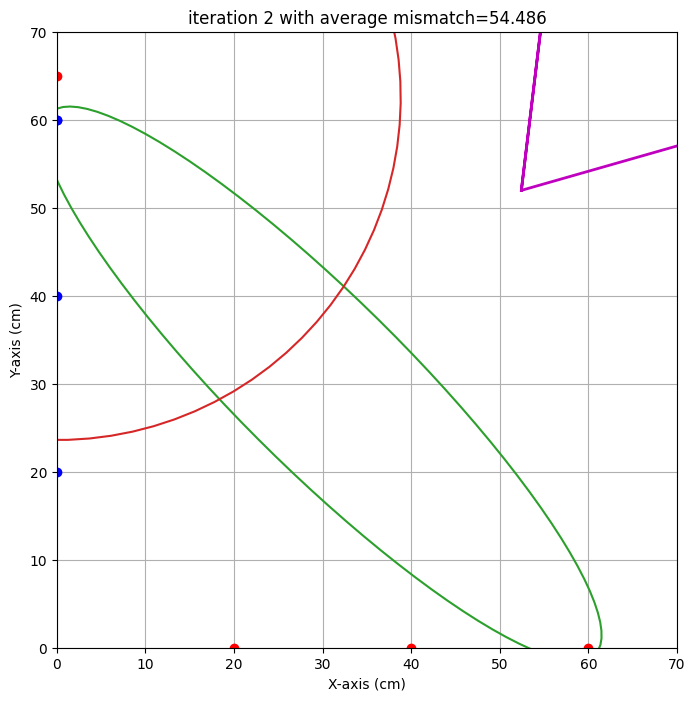

end iteration 2 with average mismatch=54.486


C:\Users\victo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


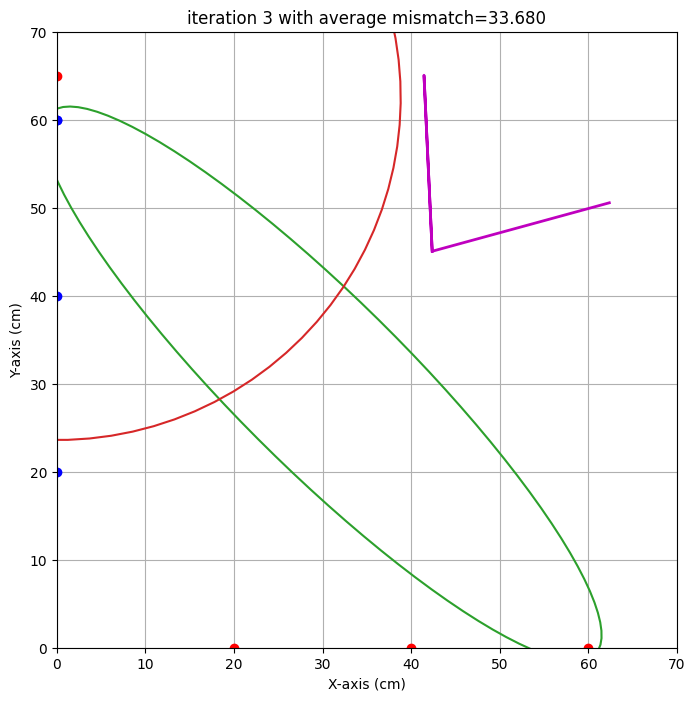

end iteration 3 with average mismatch=33.680


C:\Users\victo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


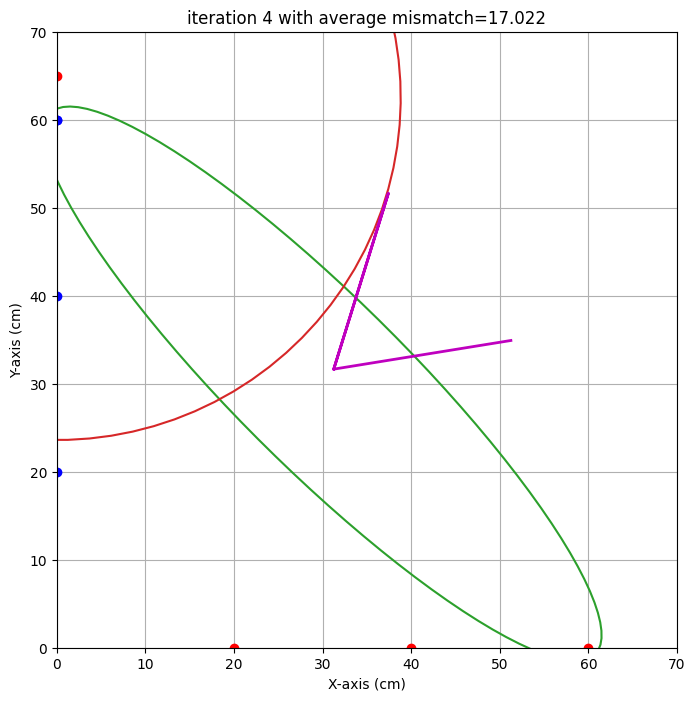

end iteration 4 with average mismatch=17.022


C:\Users\victo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


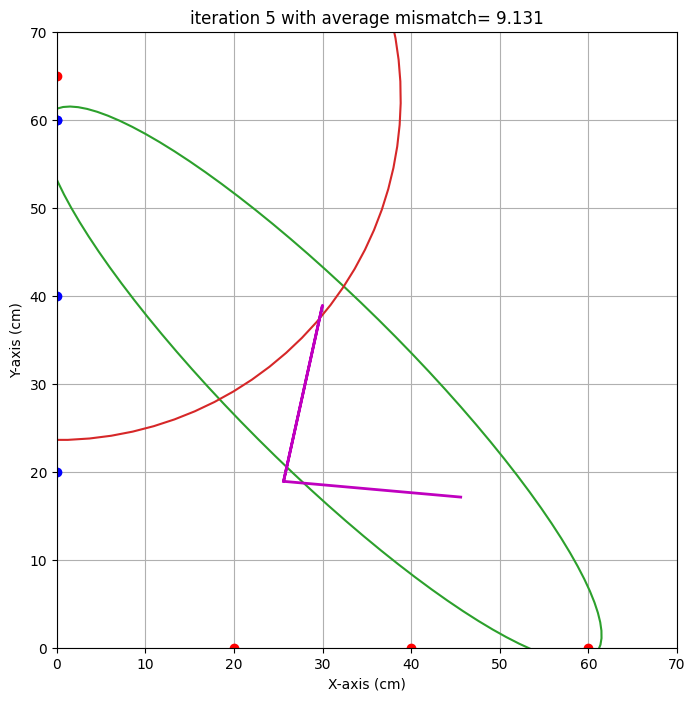

end iteration 5 with average mismatch= 9.131


C:\Users\victo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


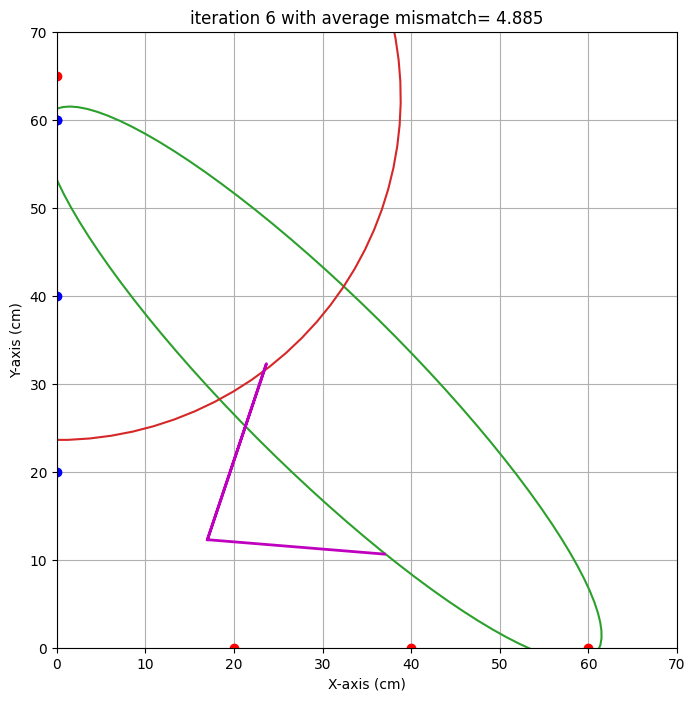

end iteration 6 with average mismatch= 4.885


C:\Users\victo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


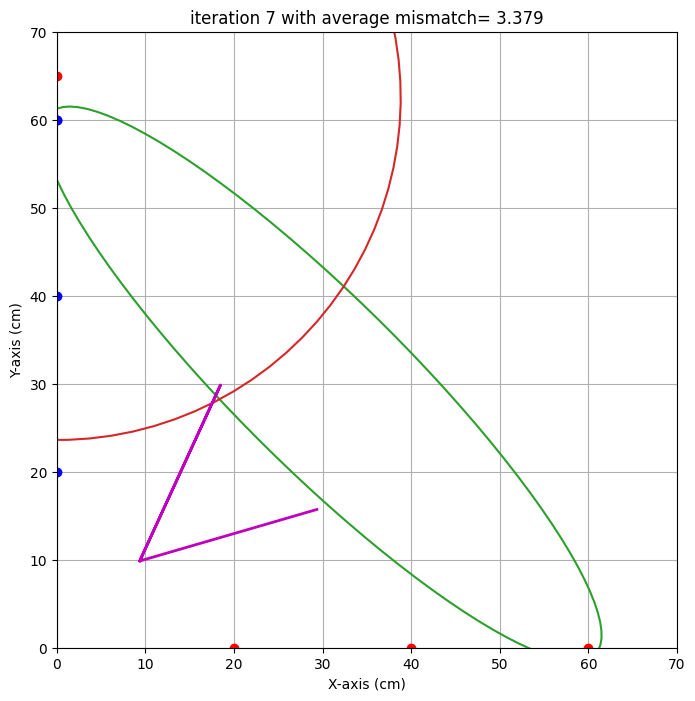

end iteration 7 with average mismatch= 3.379


C:\Users\victo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


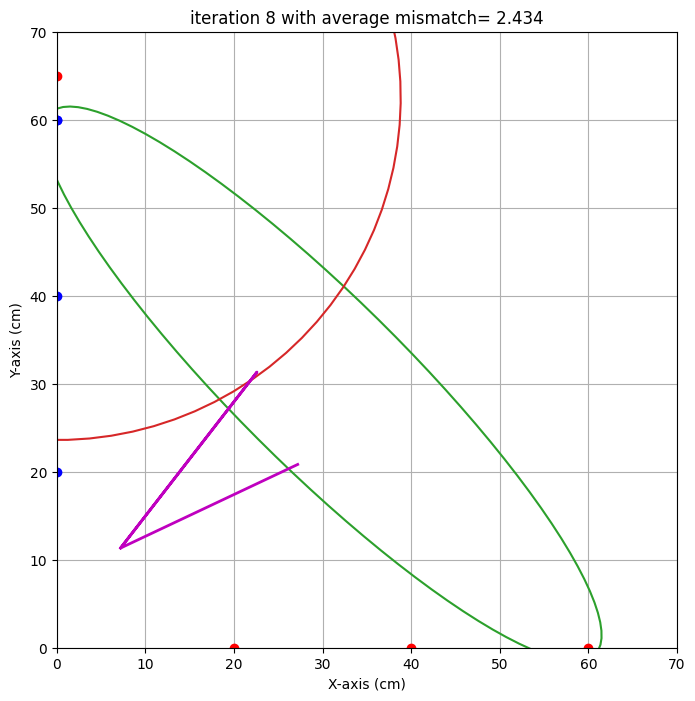

end iteration 8 with average mismatch= 2.434
end iteration 9 with average mismatch= 2.378


C:\Users\victo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


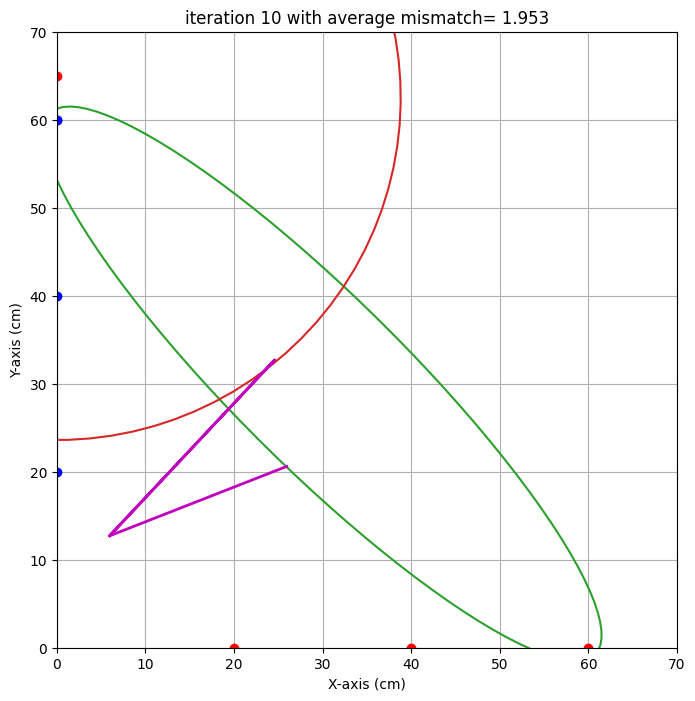

end iteration 10 with average mismatch= 1.953
end iteration 11 with average mismatch= 1.938
end iteration 12 with average mismatch= 1.938
end iteration 13 with average mismatch= 1.937
end iteration 14 with average mismatch= 1.937
end iteration 15 with average mismatch= 1.937
end iteration 16 with average mismatch= 1.937
end iteration 17 with average mismatch= 1.937
end iteration 18 with average mismatch= 1.937
end iteration 19 with average mismatch= 1.937
end iteration 20 with average mismatch= 1.937
end iteration 21 with average mismatch= 1.937
end iteration 22 with average mismatch= 1.937
end iteration 23 with average mismatch= 1.937
end iteration 24 with average mismatch= 1.937
end iteration 25 with average mismatch= 1.937
end iteration 26 with average mismatch= 1.937
end iteration 27 with average mismatch= 1.937
end iteration 28 with average mismatch= 1.937
end iteration 29 with average mismatch= 1.936
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

C:\Users\victo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


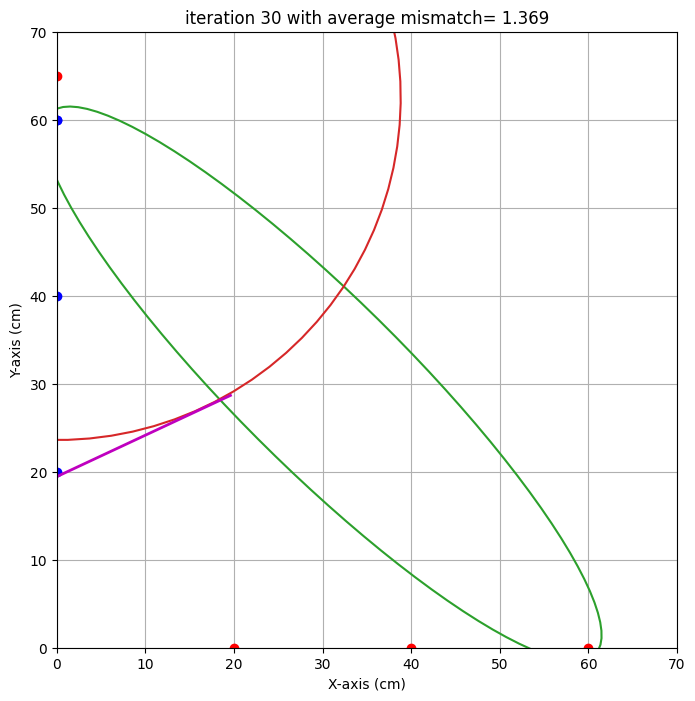

end iteration 30 with average mismatch= 1.369
###############################################################################
end of iteration  30
Best alpha=  25.21 with uncertainty=  13.00
Best beta =  -1.53 with uncertainty=  14.97
Best x0   =  -0.41 with uncertainty=   3.59
Best y0   =  19.26 with uncertainty=   3.68
###############################################################################


C:\Users\victo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


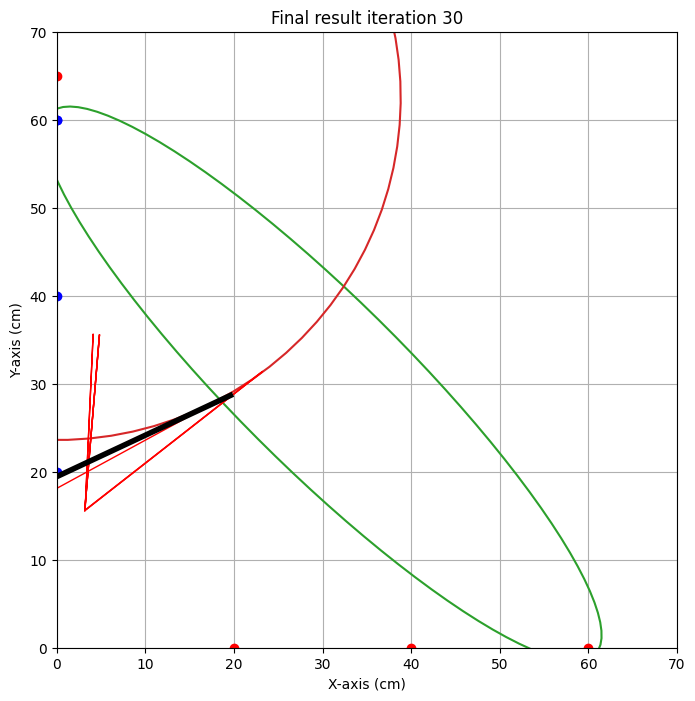

{'alpha': np.float64(25.2052095374219), 'alpha_eps': np.float64(13.000521223632141), 'beta': np.float64(-1.5272098099138773), 'beta_eps': np.float64(14.972282520179771), 'x0': np.float64(-0.40720627351897176), 'x0_eps': np.float64(3.592119197315475), 'y0': np.float64(19.256883040267198), 'y0_eps': np.float64(3.6818516945027966)}


In [10]:
# Hier runnen we het imaging algoritme:
resultaat = dict()
for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [11]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.

for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))


Tahlia 
x0 target is : 23.0. Gevonden waarde: 22.5 cm met een standaardafwijking van 3.5 cm 
y0 target is : 27.0. Gevonden waarde: 27.8 cm met een standaardafwijking van 2.2 cm 
alpha target is : 0.0. Gevonden waarde: -1.9 graden met een standaardafwijking van 9.2 graad 
beta target is : 33.0. Gevonden waarde: 25.5 graden met een standaardafwijking van 8.9 graad 

Wolf 
x0 target is : 23.0. Gevonden waarde: -0.4 cm met een standaardafwijking van 3.6 cm 
y0 target is : 27.0. Gevonden waarde: 19.3 cm met een standaardafwijking van 3.7 cm 
alpha target is : 0.0. Gevonden waarde: 25.2 graden met een standaardafwijking van 13.0 graad 
beta target is : 33.0. Gevonden waarde: -1.5 graden met een standaardafwijking van 15.0 graad 



## Opdracht 8: Iteratie1+.tijd: 15:05
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](verbeterdalgoritme_iteratie+1.png)


In [12]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  50   0  35  59.30
1  30   0  45   0  58.45
2   0  40   0  55  60.45
3  35   0  50   0  60.15


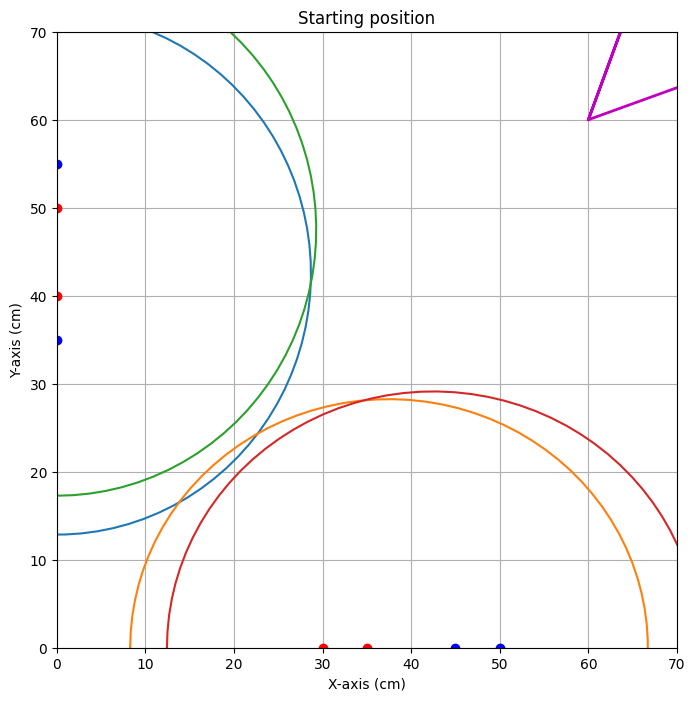


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=72.848


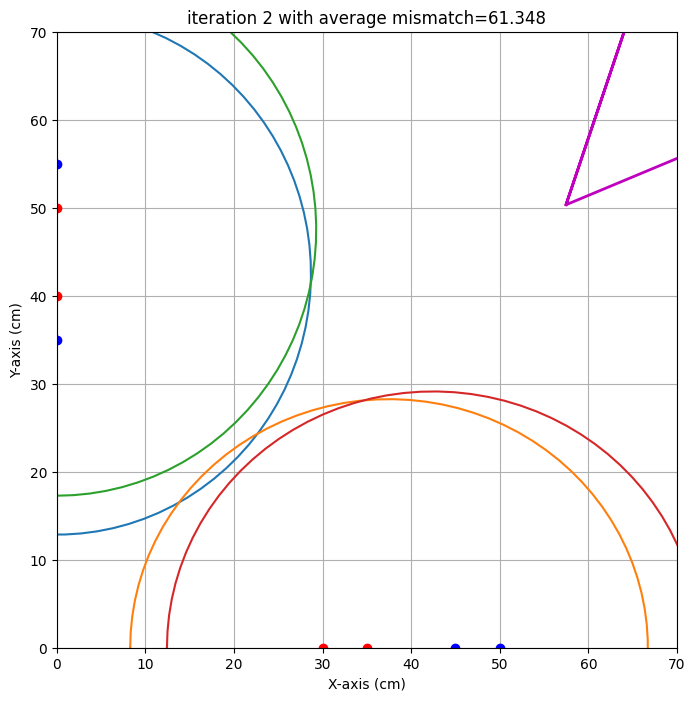

end iteration 2 with average mismatch=61.348


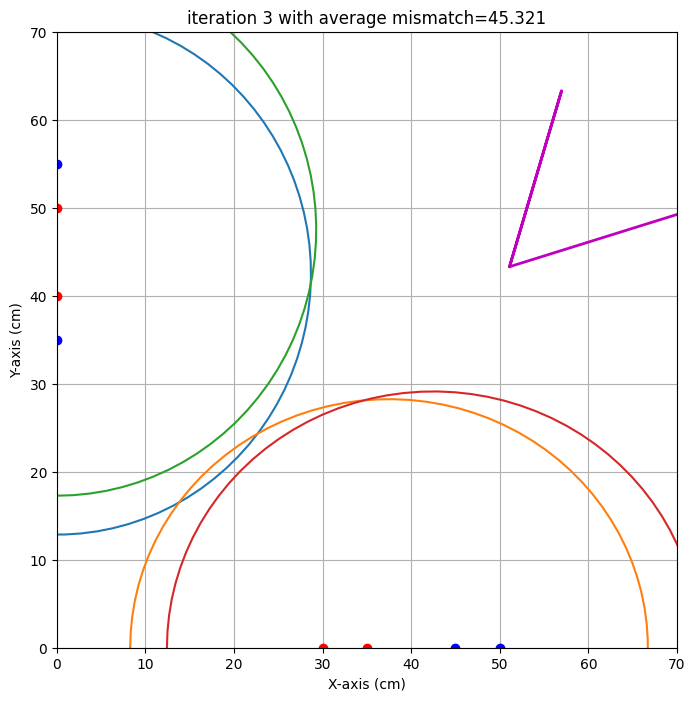

end iteration 3 with average mismatch=45.321


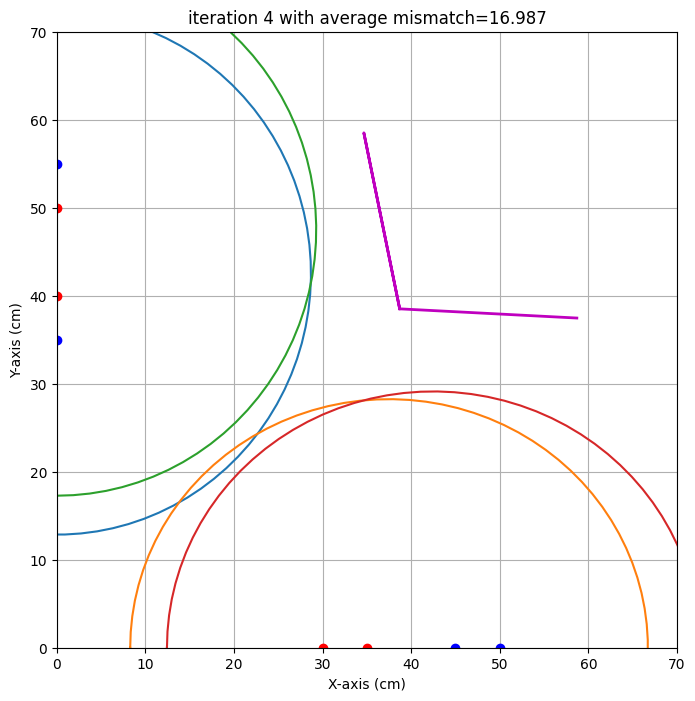

end iteration 4 with average mismatch=16.987


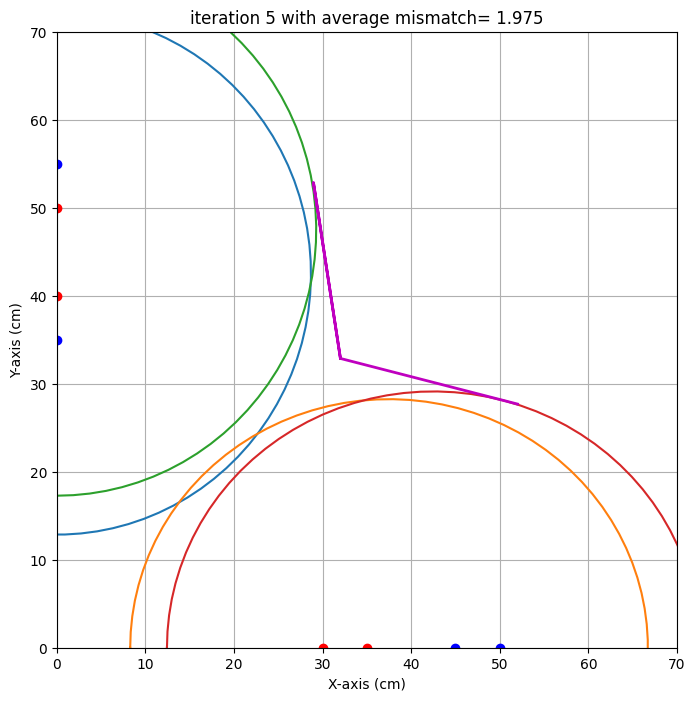

end iteration 5 with average mismatch= 1.975
end iteration 6 with average mismatch= 1.817
end iteration 7 with average mismatch= 1.756


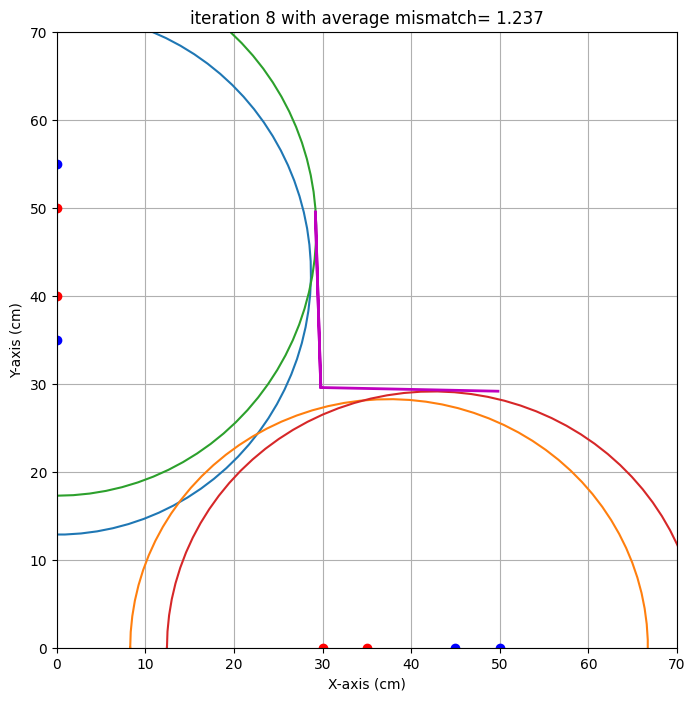

end iteration 8 with average mismatch= 1.237


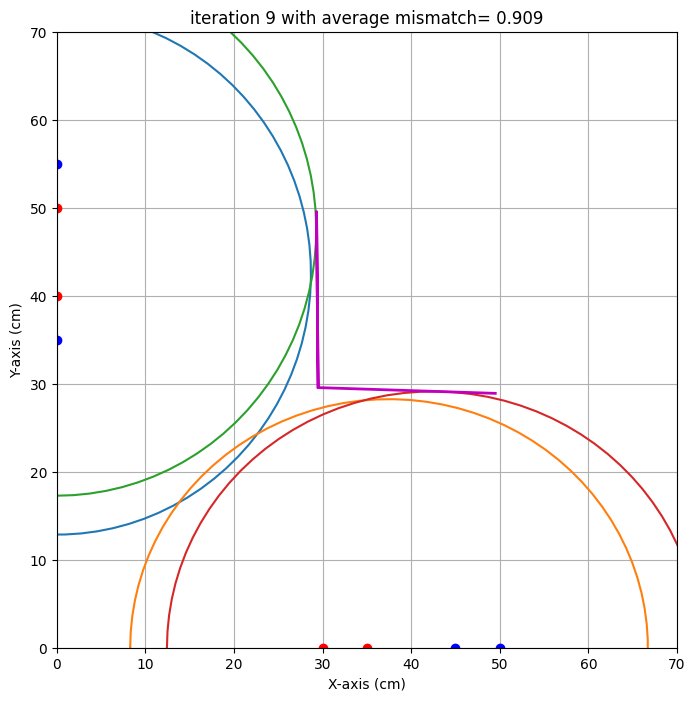

end iteration 9 with average mismatch= 0.909
end iteration 10 with average mismatch= 0.909
end iteration 11 with average mismatch= 0.909
end iteration 12 with average mismatch= 0.909
end iteration 13 with average mismatch= 0.909


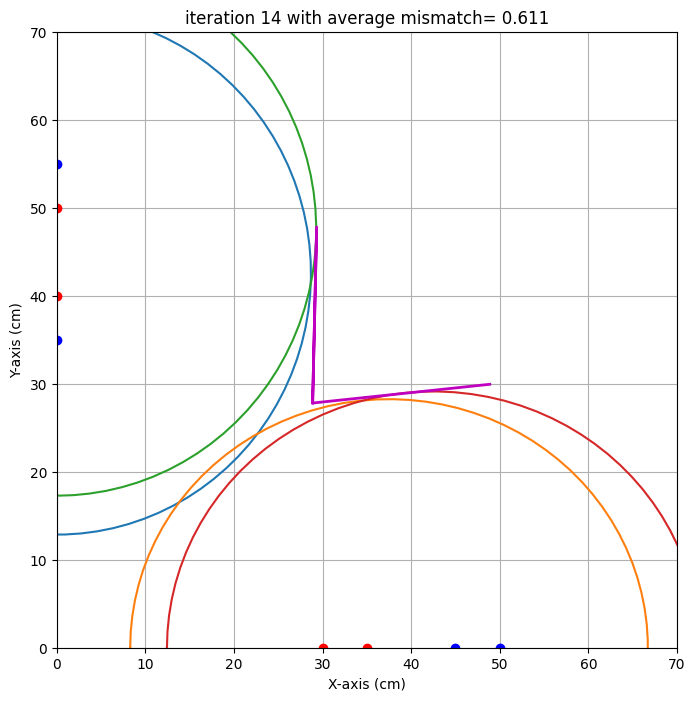

end iteration 14 with average mismatch= 0.611


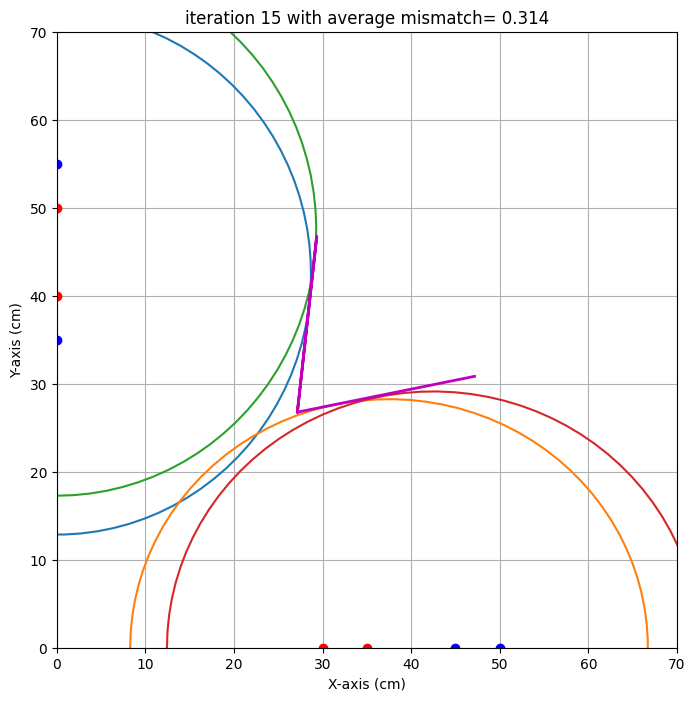

end iteration 15 with average mismatch= 0.314


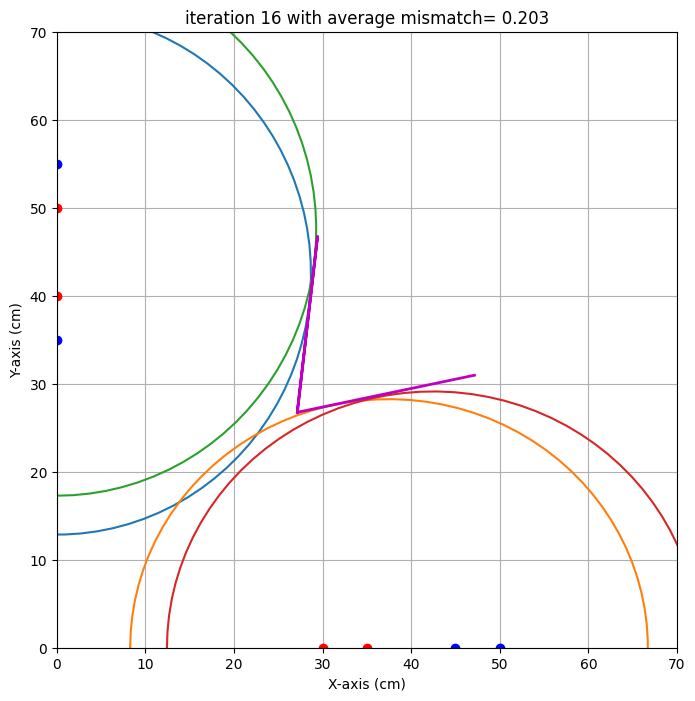

end iteration 16 with average mismatch= 0.203


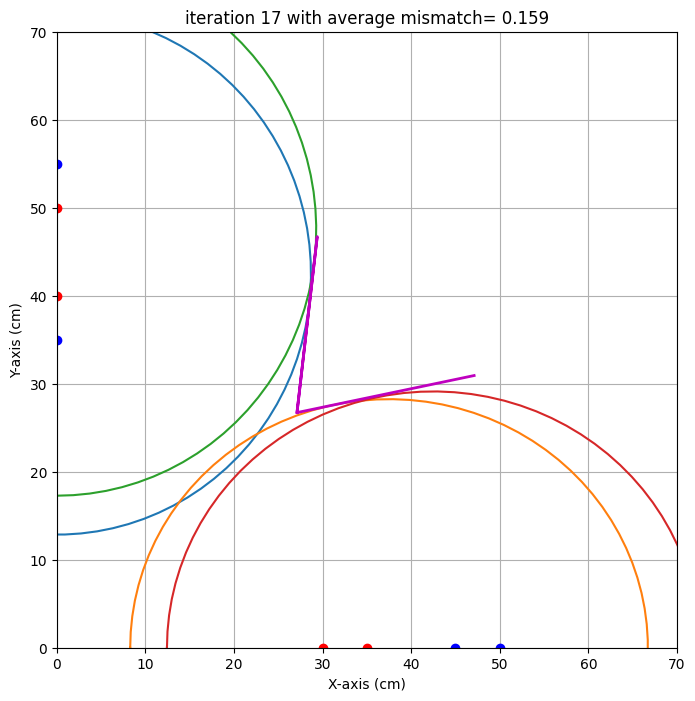

end iteration 17 with average mismatch= 0.159
end iteration 18 with average mismatch= 0.159
end iteration 19 with average mismatch= 0.159
end iteration 20 with average mismatch= 0.159
end iteration 21 with average mismatch= 0.159
end iteration 22 with average mismatch= 0.159
end iteration 23 with average mismatch= 0.159
end iteration 24 with average mismatch= 0.159
end iteration 25 with average mismatch= 0.159
end iteration 26 with average mismatch= 0.159
end iteration 27 with average mismatch= 0.159
end iteration 28 with average mismatch= 0.159
end iteration 29 with average mismatch= 0.159
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.159
###############################################################################
end of iteration  30
Best alpha=  11.89 with uncertainty=   2.37
Best beta =   6.51 with uncertainty=   7.16
Best x0   =  27.11 with uncertainty=   1.43
Best y0   =  2

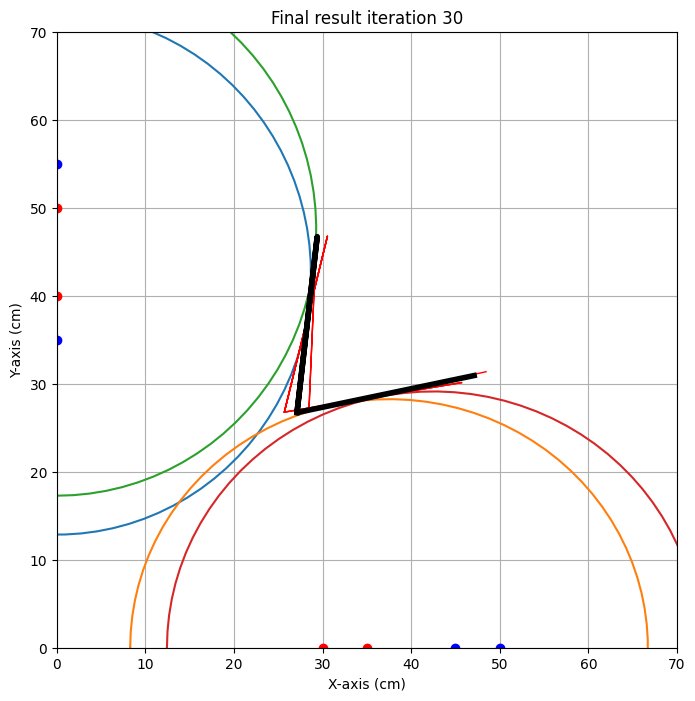

{'alpha': np.float64(11.888768150862566), 'alpha_eps': np.float64(2.3740530460321754), 'beta': np.float64(6.513440755797437), 'beta_eps': np.float64(7.164996871489934), 'x0': np.float64(27.10581824618218), 'x0_eps': np.float64(1.4262584424031282), 'y0': np.float64(26.71916297254289), 'y0_eps': np.float64(0.19686765766212133)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  50   0  35  49.17
1   0  50   0  40  49.45
2  40   0  55   0  86.70
3  35   0  50   0  86.35


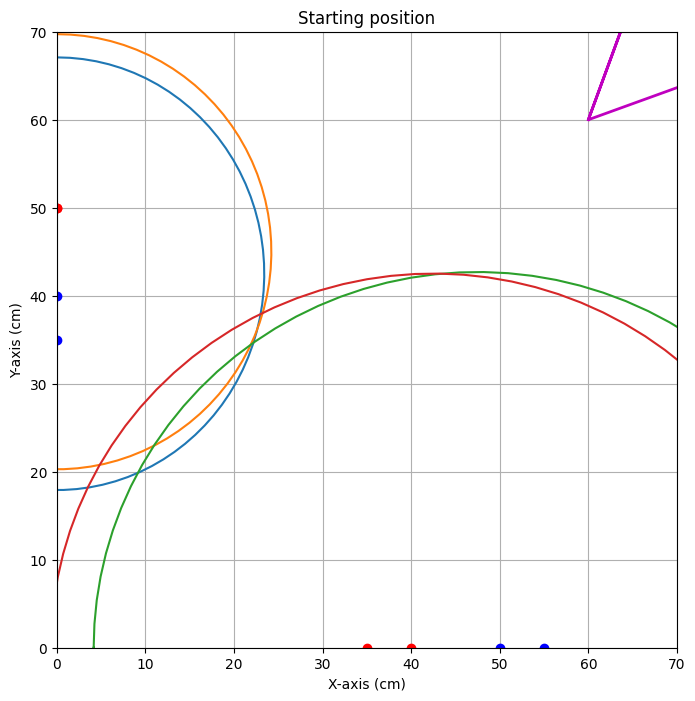


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=63.422


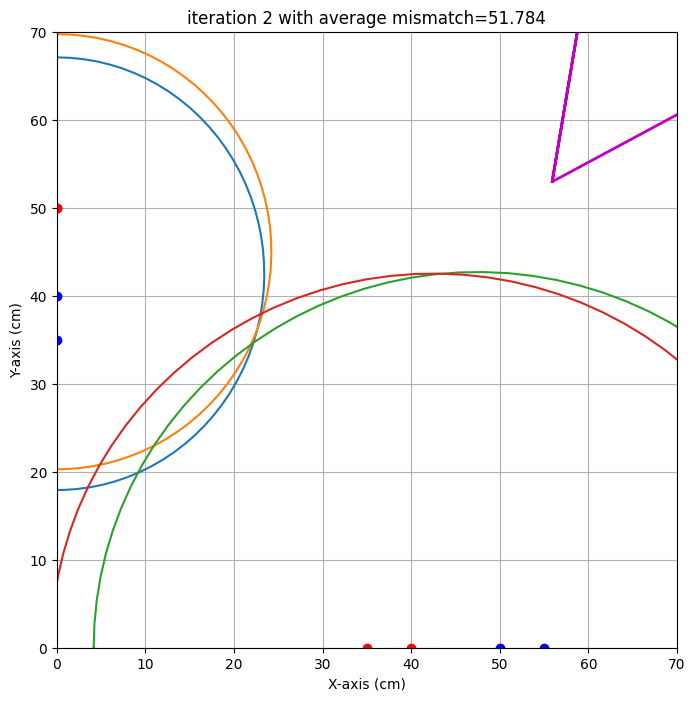

end iteration 2 with average mismatch=51.784


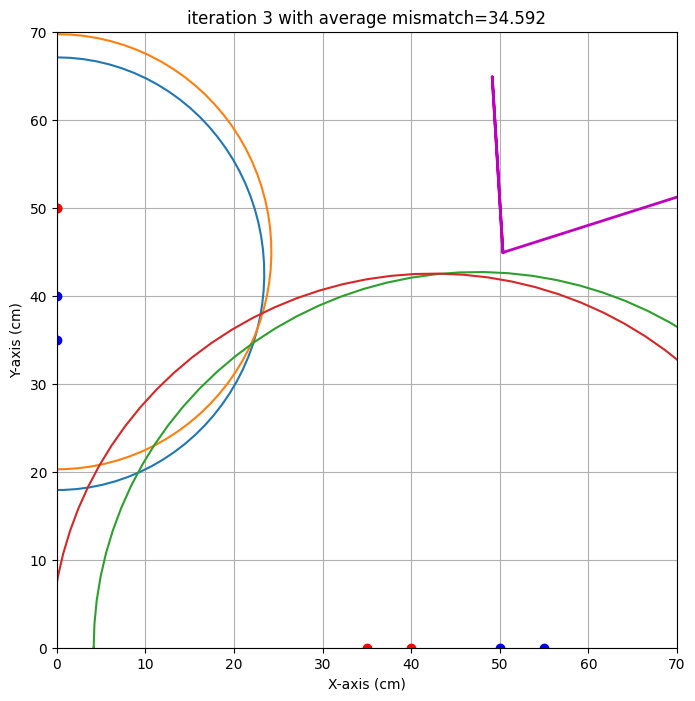

end iteration 3 with average mismatch=34.592


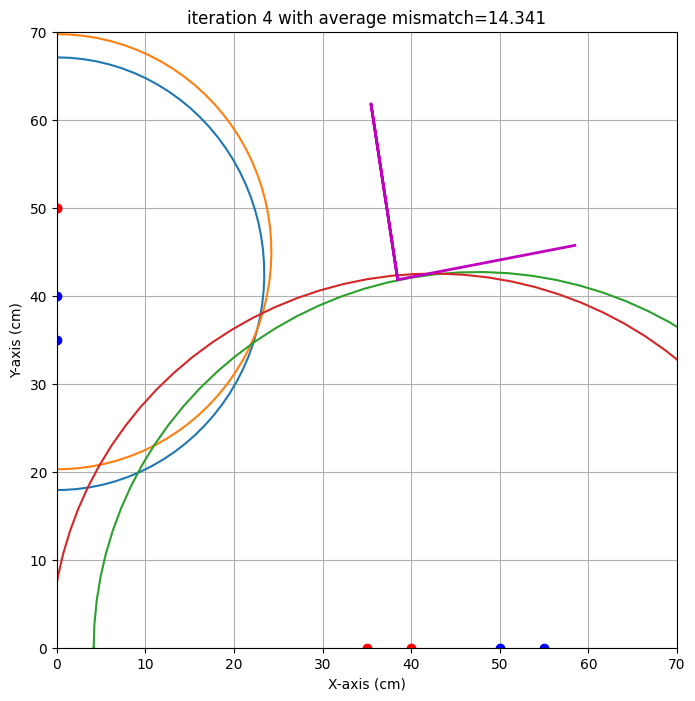

end iteration 4 with average mismatch=14.341


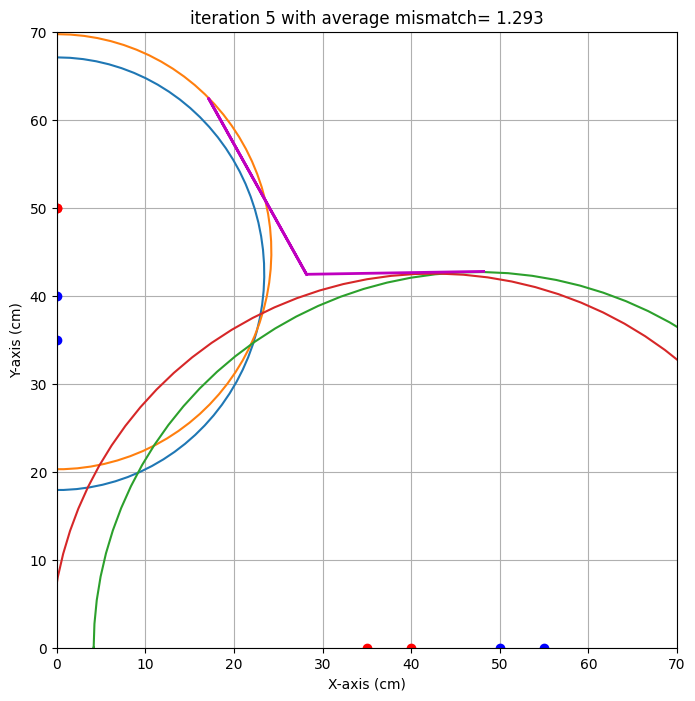

end iteration 5 with average mismatch= 1.293


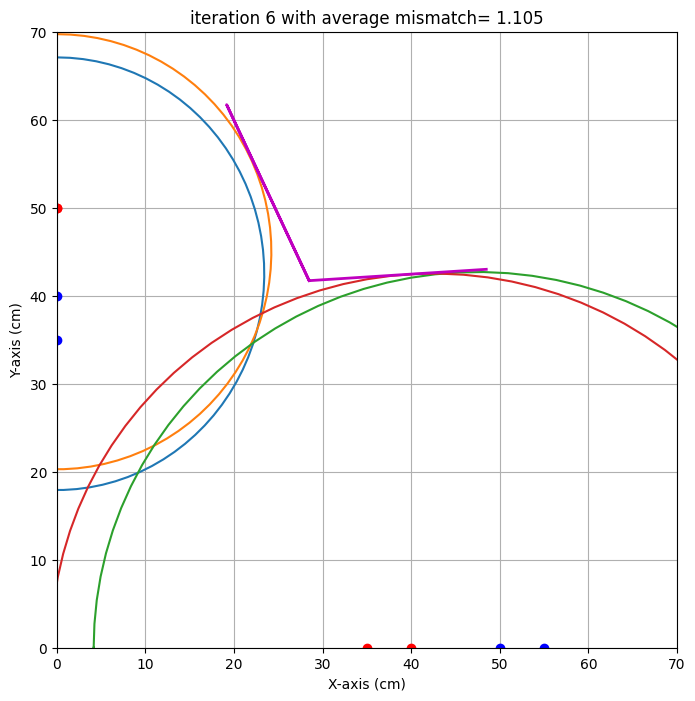

end iteration 6 with average mismatch= 1.105


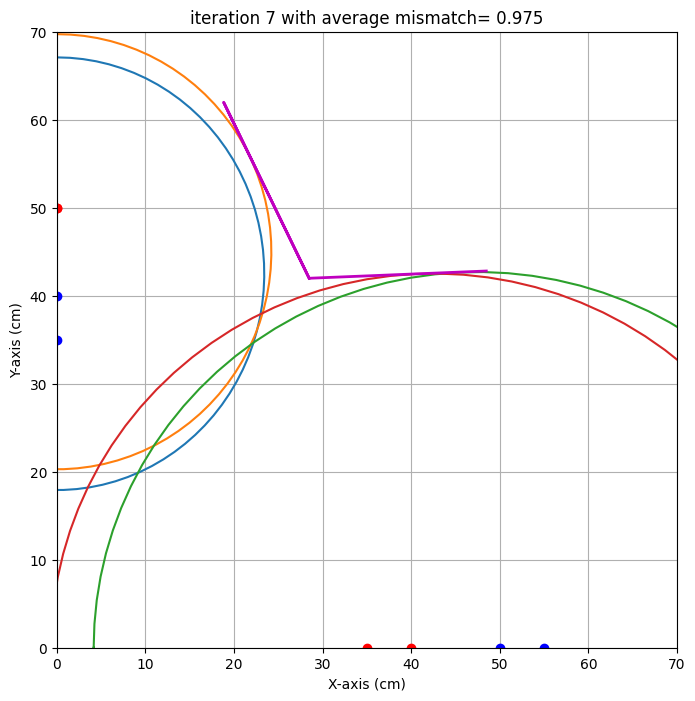

end iteration 7 with average mismatch= 0.975
end iteration 8 with average mismatch= 0.963
end iteration 9 with average mismatch= 0.960
end iteration 10 with average mismatch= 0.960
end iteration 11 with average mismatch= 0.960
end iteration 12 with average mismatch= 0.960
end iteration 13 with average mismatch= 0.960
end iteration 14 with average mismatch= 0.960
end iteration 15 with average mismatch= 0.960
end iteration 16 with average mismatch= 0.960
end iteration 17 with average mismatch= 0.960
end iteration 18 with average mismatch= 0.960
end iteration 19 with average mismatch= 0.960
end iteration 20 with average mismatch= 0.960
end iteration 21 with average mismatch= 0.960
end iteration 22 with average mismatch= 0.960
end iteration 23 with average mismatch= 0.960
end iteration 24 with average mismatch= 0.960
end iteration 25 with average mismatch= 0.960
end iteration 26 with average mismatch= 0.960
end iteration 27 with average mismatch= 0.960
end iteration 28 with average mismatc

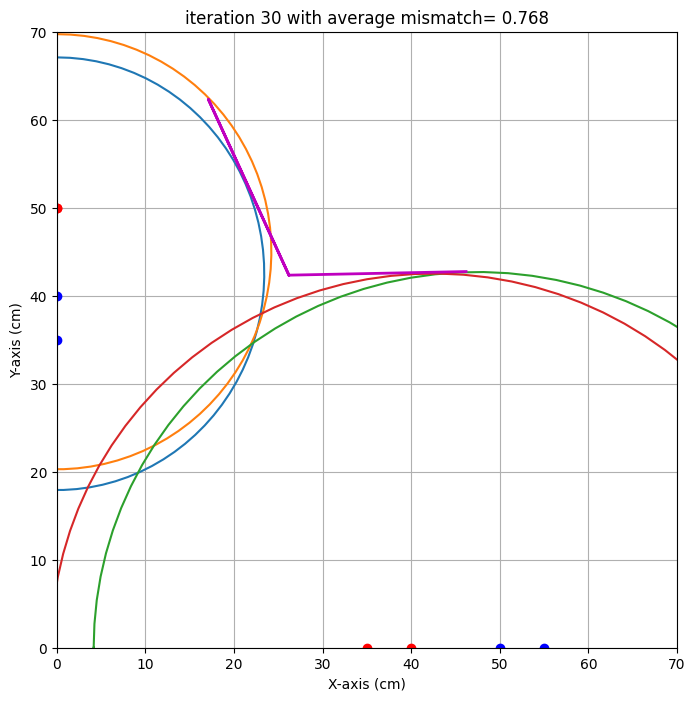

end iteration 30 with average mismatch= 0.768
###############################################################################
end of iteration  30
Best alpha=   1.17 with uncertainty=   1.05
Best beta = -24.48 with uncertainty=   1.70
Best x0   =  26.19 with uncertainty=   0.15
Best y0   =  42.34 with uncertainty=   0.53
###############################################################################


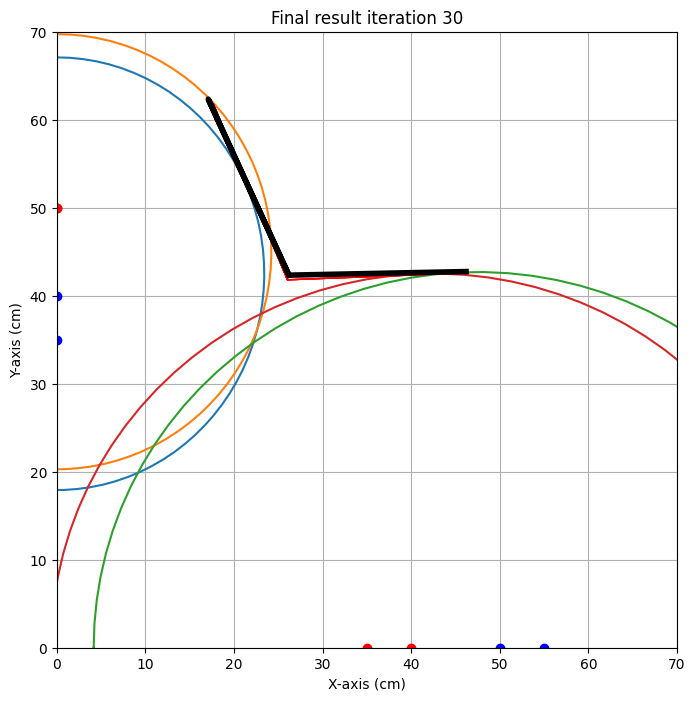

{'alpha': np.float64(1.1718747226318684), 'alpha_eps': np.float64(1.0469966405578361), 'beta': np.float64(-24.47830782026664), 'beta_eps': np.float64(1.6989893813674257), 'x0': np.float64(26.194672479987325), 'x0_eps': np.float64(0.15429179700903717), 'y0': np.float64(42.33682471524443), 'y0_eps': np.float64(0.5298980336185224)}
locatie 1 
x0 target is : 24.0. Gevonden waarde: 27.1 cm met een standaardafwijking van 1.4 cm 
y0 target is : 30.0. Gevonden waarde: 26.7 cm met een standaardafwijking van 0.2 cm 
alpha target is : 15.0. Gevonden waarde: 11.9 graden met een standaardafwijking van 2.4 graad 
beta target is : 15.0. Gevonden waarde: 6.5 graden met een standaardafwijking van 7.2 graad 

locatie 2 
x0 target is : 32.0. Gevonden waarde: 26.2 cm met een standaardafwijking van 0.2 cm 
y0 target is : 19.0. Gevonden waarde: 42.3 cm met een standaardafwijking van 0.5 cm 
alpha target is : 45.0. Gevonden waarde: 1.2 graden met een standaardafwijking van 1.0 graad 
beta target is : 10.0. G

In [13]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':24,#zelf aanvullen,
                    'y0':30,#zelf aanvullen,
                    'alpha' :15, #zelf aanvullen,
                    'beta' : 15},
           'locatie 2':{'x0': 32 ,#zelf aanvullen,
                    'y0': 19 ,#zelf aanvullen,
                    'alpha' :   45,#zelf aanvullen,
                    'beta' :   10,#zelf aanvullen}
            }}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,50,0, 35 ,59.3],
    [30,0, 45, 0, 58.45],
    #[0,5,0, 20, ongeldig],
    #[0, 55, 0,70, ongeldig],
    [0,40,0, 55, 60.45],
    [35,0, 50,0, 60.15]]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,50,0,35,49.17],
    [0,50,0,40, 49.45],
    #[30,0,45,0, ongeldig],
    [40,0,55,0,86.7],
    [35,0,50,0,86.35],
    ])
      }

                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

Figuur: ![Alt](iteratie2_laatsteverbetering.png "Title")

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  35   0  50  49.50
1   0  40   0  55  52.00
2  30   0  45   0  49.45
3  35   0  50   0  49.65


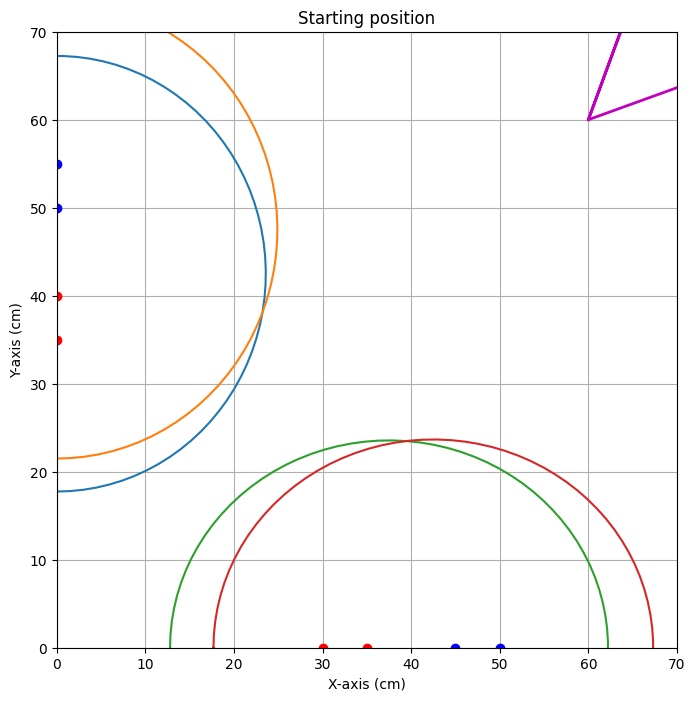


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=82.285


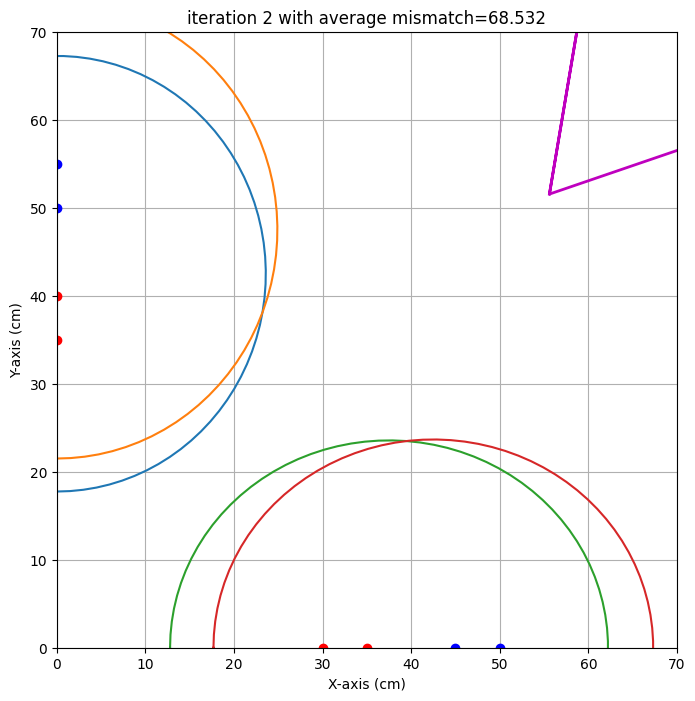

end iteration 2 with average mismatch=68.532


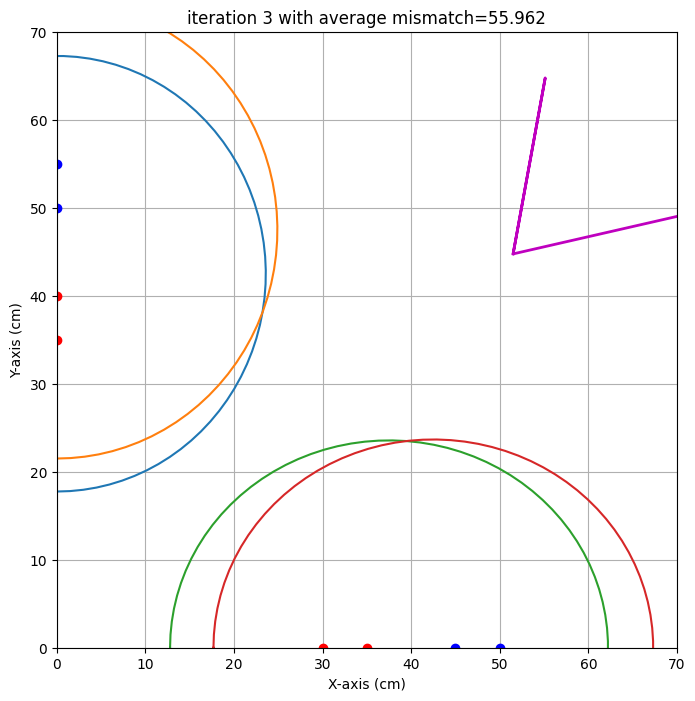

end iteration 3 with average mismatch=55.962


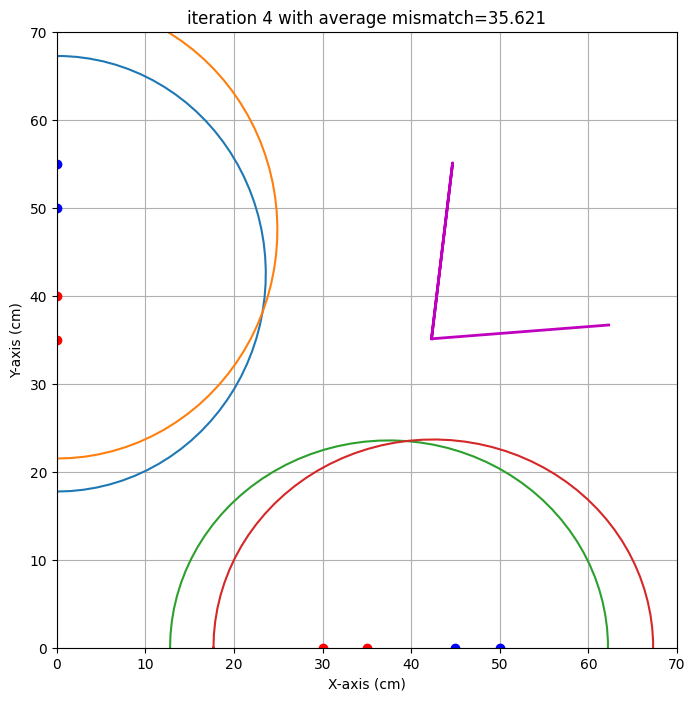

end iteration 4 with average mismatch=35.621


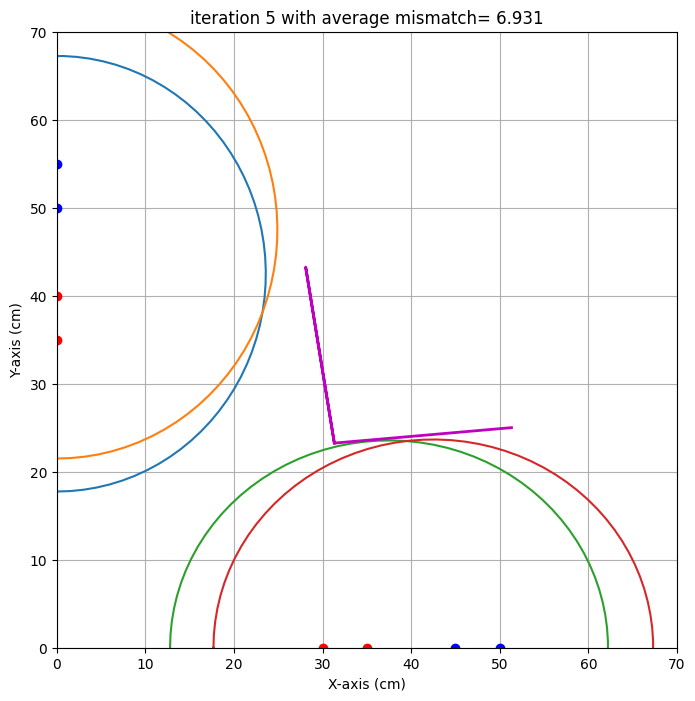

end iteration 5 with average mismatch= 6.931


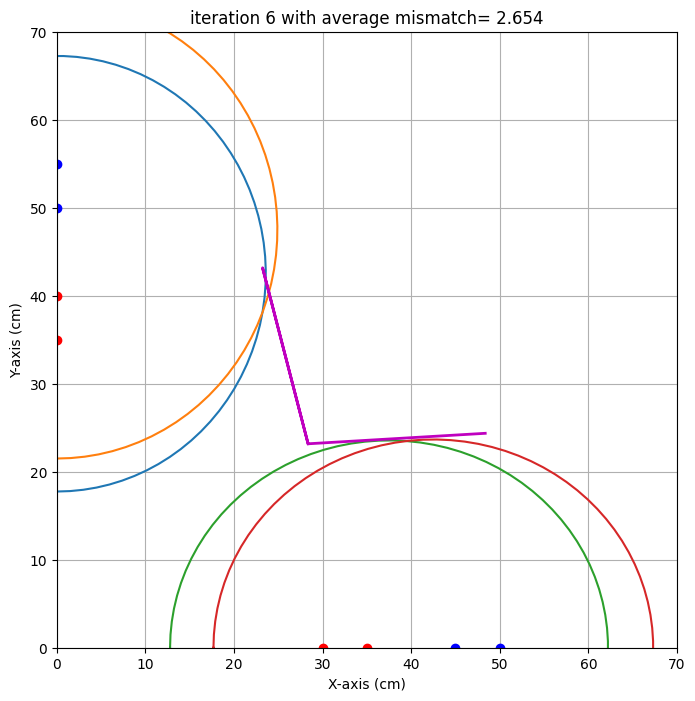

end iteration 6 with average mismatch= 2.654


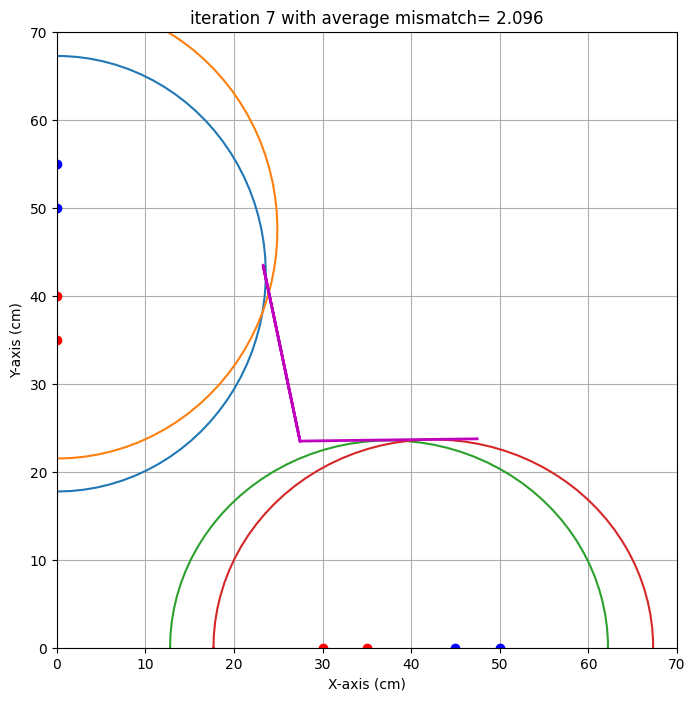

end iteration 7 with average mismatch= 2.096
end iteration 8 with average mismatch= 2.045
end iteration 9 with average mismatch= 2.001
end iteration 10 with average mismatch= 1.912
end iteration 11 with average mismatch= 1.744


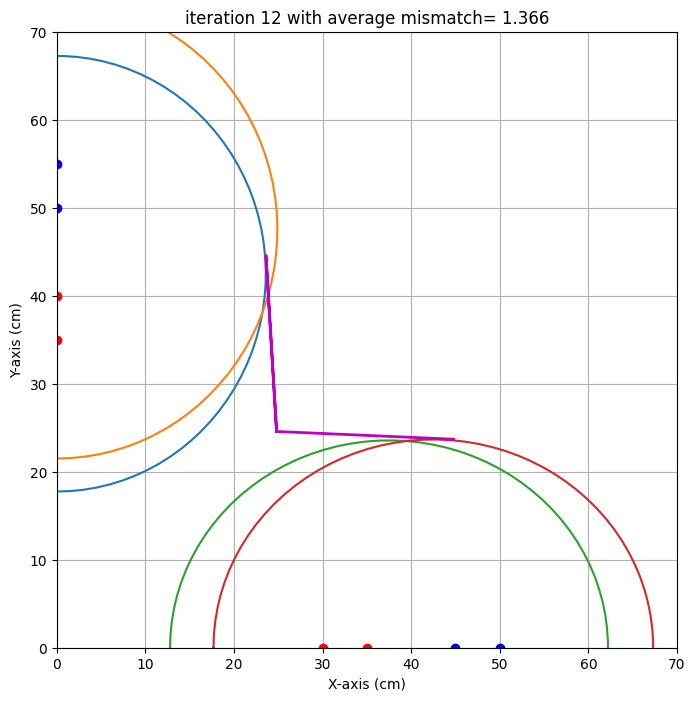

end iteration 12 with average mismatch= 1.366


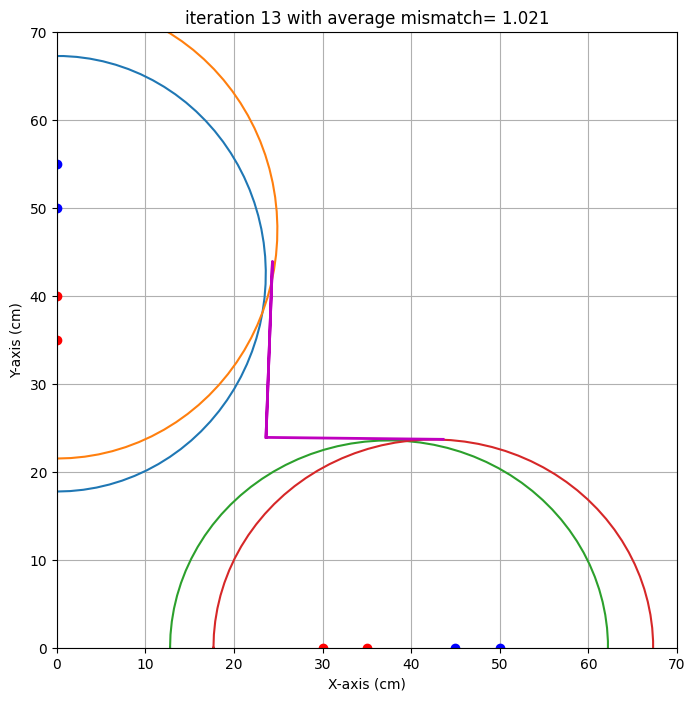

end iteration 13 with average mismatch= 1.021
end iteration 14 with average mismatch= 0.929
end iteration 15 with average mismatch= 0.881
end iteration 16 with average mismatch= 0.880


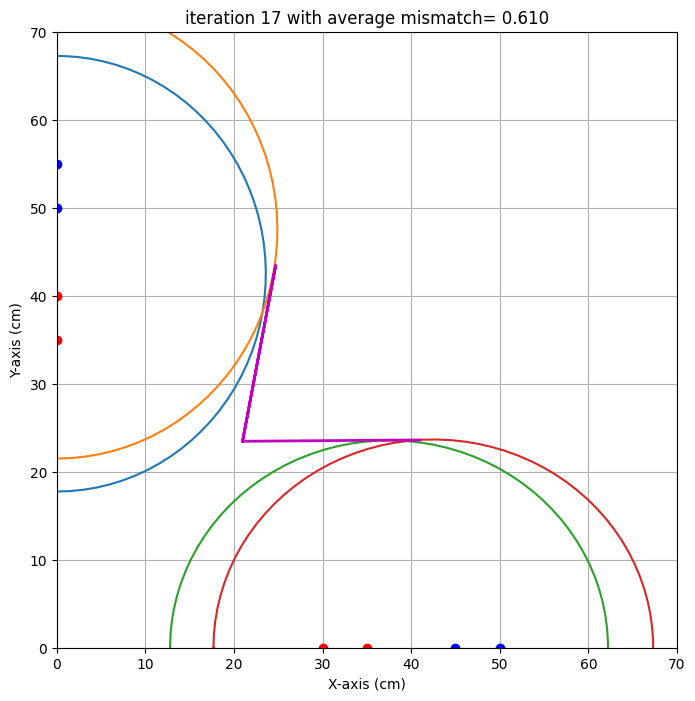

end iteration 17 with average mismatch= 0.610
end iteration 18 with average mismatch= 0.601
end iteration 19 with average mismatch= 0.594
end iteration 20 with average mismatch= 0.593
end iteration 21 with average mismatch= 0.593
end iteration 22 with average mismatch= 0.593
end iteration 23 with average mismatch= 0.593
end iteration 24 with average mismatch= 0.558
end iteration 25 with average mismatch= 0.528
end iteration 26 with average mismatch= 0.498
end iteration 27 with average mismatch= 0.469
end iteration 28 with average mismatch= 0.469
end iteration 29 with average mismatch= 0.469
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.469
###############################################################################
end of iteration  30
Best alpha=   2.35 with uncertainty=   8.23
Best beta =  12.05 with uncertainty=   5.98
Best x0   =  20.25 with uncertainty=   2.54
Best y0   =  2

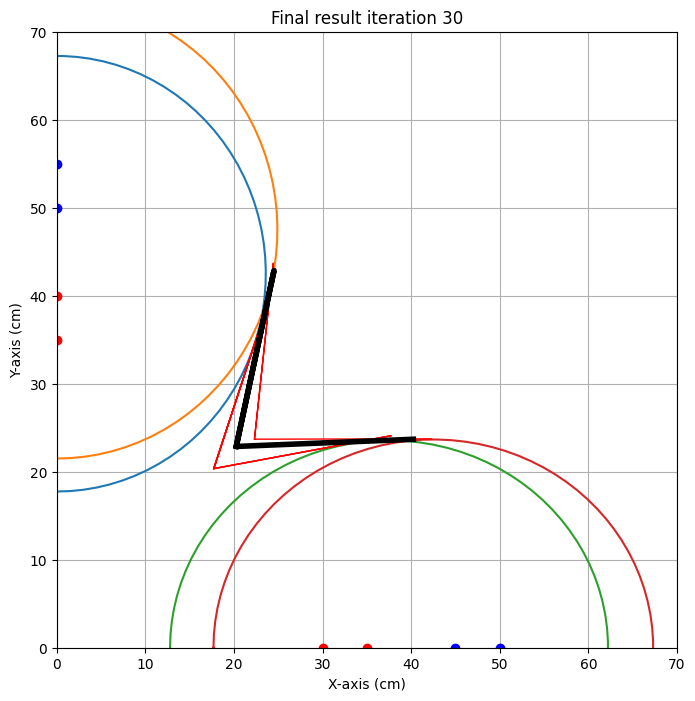

{'alpha': np.float64(2.3459895046881836), 'alpha_eps': np.float64(8.230747827967871), 'beta': np.float64(12.047635212102037), 'beta_eps': np.float64(5.983326889858309), 'x0': np.float64(20.246007850283284), 'x0_eps': np.float64(2.5370590297386713), 'y0': np.float64(22.870677114360436), 'y0_eps': np.float64(2.5170631685475016)}
test locatie 
x0 target is : 21.0. Gevonden waarde: 20.2 cm met een standaardafwijking van 2.5 cm 
y0 target is : 20.0. Gevonden waarde: 22.9 cm met een standaardafwijking van 2.5 cm 
alpha target is : 11.0. Gevonden waarde: 2.3 graden met een standaardafwijking van 8.2 graad 
beta target is : 9.0. Gevonden waarde: 12.0 graden met een standaardafwijking van 6.0 graad 



In [14]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 21, # zelf aanvullen,
                    'y0':  20,# zelf aanvullen,
                    'alpha' :  11,# zelf aanvullen,
                    'beta' : 9 # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [0,35,0, 50 ,49.50],
                    [0,40,0, 55 ,52.00],
                    [30,0,45,0, 49.45],
                    [35,0,50,0,49.65]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Het algoritme met zijn verbeteringen is hieronder weergegeven in drie versies:


<img src="fototahlia.png" width="400">
Begin met het meten in de midde met allebei de sensoren 15 cm van elkaar af. Als een van de twee metingen iets op pakt, schuif de sensoren dan een stukje op en meet opnieuw. Als beide nika op pakt, zet de sneoren weer pp de y-as dichtbij de origin en meet opnieuw, en dan op de x-as ver weg van de origin en maak nog een meting. als de laatste twee metingen ook iets oppakken beweeg ze een klein beetje en meet opnieuw.
//
<img src="verbeterdalgoritme_iteratie+1.png" width="400">

 Deze eerste versie werkte niet omdat als de sensoren dichtbij en verweg van de origin zaten dan missen we een hele hoek van het opppervlak. daarom moeten alleen op een as blijven als onze twee middelste metingen niet gelukt zijn.Begin hetzelfde met eerst in de midden van de as meten, maar nu als die iets oppakt beweeg de sensoren 5cm en meet opnieuw, dan ga naar de andere as, meet weer in het midden en als de sensor iets oppakt, schrijf de meting op en beweeg 5cm van het punt vandaan. Als geen van beide midden punten gelukt zijn, blijf dan op een as, meet een keertje dichtbij de origin en een keertje verweg van de origin om het hele oppervlak over te gaan. 

<img src="iteratie2_laatsteverbetering.png" width="400">


Als de middelste twee metingen niet gelukt zijn en je op de rand punten van het as meet, begin dan eerst aan de verste kant en als die lukt beweeg dan 5cm dichterbij. als die niet lukt begin dan dichtbij de orogin, als die gelukt is meet dan 5cm verder op in de positiefe richting. wanneer de middelste metingen lukken beweeg dan ook eerst 5cm in de positiefe richting en als die niet lukken in de negatieve richting. dit is voor consistentie. Dit is een systematische aanpak, waarvoor we uiteindelijk alleen 4 metingen nodig hadden om het object's locatie nauwkeurig te bepalen. 
